# Проект: Обучение с учителем: качество модели

**Описание проекта**

Интернет-магазин «В один клик» продаёт разные товары: для детей, для дома, мелкую бытовую технику, косметику и даже продукты. Отчёт магазина за прошлый период показал, что активность покупателей начала снижаться. Привлекать новых клиентов уже не так эффективно: о магазине и так знает большая часть целевой аудитории. Возможный выход — удерживать активность постоянных клиентов. Сделать это можно с помощью персонализированных предложений.

«В один клик» — современная компания, поэтому её руководство не хочет принимать решения просто так — только на основе анализа данных и бизнес-моделирования. У компании есть небольшой отдел цифровых технологий, и нам предстоит побыть в роли стажёра в этом отделе. 

Итак, нашему отделу поручили разработать решение, которое позволит персонализировать предложения постоянным клиентам, чтобы увеличить их покупательскую активность.

**Установим библиотеки нужной версии:**

In [1]:
# !pip install numpy==1.26.4 

In [2]:
!pip install matplotlib==3.5.0

In [3]:
!pip install -q --upgrade scikit-learn

In [4]:
!pip install shap 

In [5]:
# !pip install -q --upgrade shap

In [6]:
!pip install phik

**Импортируем все необходимые библиотеки для исследования:**

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import sklearn
import phik
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler, MinMaxScaler
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score
import shap
from sklearn.inspection import permutation_importance

## Загрузка данных

### Загрузим данные

Считаем CSV-файлы с данными с помощью библиотеки pandas и сохраним их в датафреймы.

Путь к файлам:
- `'/datasets/market_file.csv'`
- `'/datasets/market_money.csv'`
- `'/datasets/market_time.csv'`
- `'/datasets/money.csv'`

In [8]:
market_file = pd.read_csv('/datasets/market_file.csv') 
market_money = pd.read_csv('/datasets/market_money.csv')
market_time = pd.read_csv('/datasets/market_time.csv')
money = pd.read_csv('/datasets/money.csv')

Выведем первые строки датафреймов, чтобы проверить, правильно ли считались данные:

In [9]:
market_file.head(3)

,id,Покупательская активность,Тип сервиса,Разрешить сообщать,Маркет_актив_6_мес,Маркет_актив_тек_мес,Длительность,Акционные_покупки,Популярная_категория,Средний_просмотр_категорий_за_визит,Неоплаченные_продукты_штук_квартал,Ошибка_сервиса,Страниц_за_визит
0,215348,Снизилась,премиум,да,3.4,5,121,0.00,Товары для детей,6,2,1,5
1,215349,Снизилась,премиум,да,4.4,4,819,0.75,Товары для детей,4,4,2,5
2,215350,Снизилась,стандартт,нет,4.9,3,539,0.14,Домашний текстиль,5,2,1,5


In [10]:
market_money.head(3)

,id,Период,Выручка
0,215348,препредыдущий_месяц,0.0
1,215348,текущий_месяц,3293.1
2,215348,предыдущий_месяц,0.0


In [11]:
market_time.head(3)

,id,Период,минут
0,215348,текущий_месяц,14
1,215348,предыдцщий_месяц,13
2,215349,текущий_месяц,10


In [12]:
money.head(3)

,id;Прибыль
215348;0,98.0
215349;4,16.0
215350;3,13.0


Из вывода датафреймов можно сказать, что разделяющим параметром в файле `money.csv` *не является запятая*, как в других, поэтому в качестве передаваемого параметра аргументу `sep` нужно передать `;`, так как именно он является *разделяющим* в нашем csv-файле.Также, чтобы не заниматься ручным приведением строк в числа, укажем параметр `decimal=','` - при чтении будет сразу определено, что запятая - это разделитель целой и дробной части в десятичных дробях. Остальные же файлы считались правильно.

Проделаем те же самые шаги, но теперь при считывании файла зададим параметр `sep=';'` и `decimal=','`:

In [13]:
money = pd.read_csv('/datasets/money.csv', sep=';', decimal=',')

In [14]:
money.head(3)

,id,Прибыль
0,215348,0.98
1,215349,4.16
2,215350,3.13


Теперь можно говорить о том, что CSV-файлы считались правильно, и с такими датафреймами уже можно работать.

### Изучим общую информацию о датафреймах

Теперь для лучшего понимания данных, хранящихся в датафреймах, выведем информацию о них методом `.info()`:

In [15]:
market_file.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1300 entries, 0 to 1299
Data columns (total 13 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   id                                   1300 non-null   int64  
 1   Покупательская активность            1300 non-null   object 
 2   Тип сервиса                          1300 non-null   object 
 3   Разрешить сообщать                   1300 non-null   object 
 4   Маркет_актив_6_мес                   1300 non-null   float64
 5   Маркет_актив_тек_мес                 1300 non-null   int64  
 6   Длительность                         1300 non-null   int64  
 7   Акционные_покупки                    1300 non-null   float64
 8   Популярная_категория                 1300 non-null   object 
 9   Средний_просмотр_категорий_за_визит  1300 non-null   int64  
 10  Неоплаченные_продукты_штук_квартал   1300 non-null   int64  
 11  Ошибка_сервиса                

In [16]:
market_money.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   id       3900 non-null   int64  
 1   Период   3900 non-null   object 
 2   Выручка  3900 non-null   float64
dtypes: float64(1), int64(1), object(1)
memory usage: 91.5+ KB


In [17]:
market_time.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2600 entries, 0 to 2599
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      2600 non-null   int64 
 1   Период  2600 non-null   object
 2   минут   2600 non-null   int64 
dtypes: int64(2), object(1)
memory usage: 61.1+ KB


In [18]:
money.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1300 entries, 0 to 1299
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   id       1300 non-null   int64  
 1   Прибыль  1300 non-null   float64
dtypes: float64(1), int64(1)
memory usage: 20.4 KB


Проанализировав информацию о датафреймах, можно говорить, что все типы данных **соответствуют** в действительности самим данным - то есть необходимости изменять их тип - **нет**.

**Промежуточный вывод:**

В результате загрузки данных были выполнены следующие шаги:
- загрузили CSV-файлы с правильным разделяющим параметром
- изучили основную информацию о датафреймах
- определили, что типы данных соответствуют действительности
- было определено, что необходимо преобразовать названия столбцов - привести к правильному виду записи (прописные буквы, "змеевидная" запись(через нижнее подчеркивание))(проделаем это в следующем шаге)

## Предобработка данных

Проведем предобработку данных.

### Проверим наличие пропусков в данных

Воспользуемся методом `.isna()` для поиска пропусков во всех датафреймах и просуммируем их методом `.sum()`:

In [19]:
market_file.isna().sum()

id                                     0
Покупательская активность              0
Тип сервиса                            0
Разрешить сообщать                     0
Маркет_актив_6_мес                     0
Маркет_актив_тек_мес                   0
Длительность                           0
Акционные_покупки                      0
Популярная_категория                   0
Средний_просмотр_категорий_за_визит    0
Неоплаченные_продукты_штук_квартал     0
Ошибка_сервиса                         0
Страниц_за_визит                       0
dtype: int64

In [20]:
market_money.isna().sum()

id         0
Период     0
Выручка    0
dtype: int64

In [21]:
market_time.isna().sum()

id        0
Период    0
минут     0
dtype: int64

In [22]:
money.isna().sum()

id         0
Прибыль    0
dtype: int64

Из результатов вывода видно, что пропущенных значений во всех датафреймах нет. Это является *очень хорошим* показателем.

### Проверим данные на наличие дубликатов

После проверки датафрейма на наличие пропусков, проверим его на наличие дубликатов:

Воспользуемся методом `.duplicated()`, чтобы найти *явные* дубликаты в датафрейме и после методом `.sum()` выведем их количество:

In [23]:
market_file.duplicated().sum()

0

In [24]:
market_money.duplicated().sum()

0

In [25]:
market_time.duplicated().sum()

0

In [26]:
money.duplicated().sum()

0

В результате наблюдаем, что *явных* дубликатов нет.

Теперь проверим данные на наличие *неявных* дубликатов, которые также могут встретиться. Для этого необходимо будет проверить все категориальные столбцы с данными на уникальность методом `.unique()`. Так как столбцов с данными много, то для оптимизации работы напишем функцию `unique_search()`: в неё будем передавать датафрейм, его имя(строкой) и названия столбцов категориальных переменных:

In [27]:
def unique_search(dataframe, df_name , data_list):
    for i in data_list:
        print('\nДатафрейм ' + df_name + ', столбец <' + i + '>:\n')
        print(dataframe[i].unique())

Применим функцию `unique_search()` к датафреймам `market_file`, `market_money`, `market_time` и после проанализируем результаты вывода(датафрейм `money` не содержит категориальных переменных, поэтому его рассматривать не будем):

In [28]:
unique_search(market_file, 'market_file', market_file.drop(columns = market_file.describe().columns).columns)


Датафрейм market_file, столбец <Покупательская активность>:

['Снизилась' 'Прежний уровень']

Датафрейм market_file, столбец <Тип сервиса>:

['премиум' 'стандартт' 'стандарт']

Датафрейм market_file, столбец <Разрешить сообщать>:

['да' 'нет']

Датафрейм market_file, столбец <Популярная_категория>:

['Товары для детей' 'Домашний текстиль' 'Косметика и аксесуары'
 'Техника для красоты и здоровья' 'Кухонная посуда'
 'Мелкая бытовая техника и электроника']


In [29]:
unique_search(market_money, 'market_money', market_money.drop(columns = market_money.describe().columns).columns)


Датафрейм market_money, столбец <Период>:

['препредыдущий_месяц' 'текущий_месяц' 'предыдущий_месяц']


In [30]:
unique_search(market_time, 'market_time', market_time.drop(columns = market_time.describe().columns).columns)


Датафрейм market_time, столбец <Период>:

['текущий_месяц' 'предыдцщий_месяц']


Из результатов проверки на уникальность видно, что есть данные в столбцах, которые написаны либо неправильно, либо обозначают одно и тоже. 

Создадим функцию `redactation_column_dupl()`, в которую будет передаваться датафрейм; после этого будем производиься замена названий столбцов к правильному виду, а также приведены все данные к нижнему регистру и через нижнее подчеркивание в ячейках датафрейма с помощбю lambda-функции:

In [31]:
def redactation_column_dupl(dataframe):
    old_names = dataframe.columns
    new_names = []
    for i in range (len(old_names)):
        new_names.append(old_names[i].lower().replace(' ','_'))
    for i in range(len(new_names)):
        dataframe = dataframe.rename(columns={old_names[i] : new_names[i]})
    df_categ_col = dataframe.drop(columns = dataframe.describe().columns).columns
    for i in range(len(df_categ_col)):
        dataframe[df_categ_col[i]] = dataframe[df_categ_col[i]].apply(lambda x: x.lower().replace(' ','_'))
    return dataframe

Применим функцию `redactation_column_dupl()` ко всем имеющимся датафреймам:

In [32]:
market_file = redactation_column_dupl(market_file)
market_money = redactation_column_dupl(market_money)
market_time = redactation_column_dupl(market_time)
money = redactation_column_dupl(money)

Заменим методом `.replace()` неправильные названия в ячейках столбцов датафрейма:

In [33]:
market_file['тип_сервиса'] = market_file['тип_сервиса'].replace('стандартт','стандарт')
market_time['период'] = market_time['период'].replace('предыдцщий_месяц','предыдущий_месяц')

Повторно вызовем для проверки функцию `unique_search()` к датафреймам, чтобы убедиться в изменении нами данных:

In [34]:
unique_search(market_file, 'market_file', market_file.drop(columns = market_file.describe().columns).columns)


Датафрейм market_file, столбец <покупательская_активность>:

['снизилась' 'прежний_уровень']

Датафрейм market_file, столбец <тип_сервиса>:

['премиум' 'стандарт']

Датафрейм market_file, столбец <разрешить_сообщать>:

['да' 'нет']

Датафрейм market_file, столбец <популярная_категория>:

['товары_для_детей' 'домашний_текстиль' 'косметика_и_аксесуары'
 'техника_для_красоты_и_здоровья' 'кухонная_посуда'
 'мелкая_бытовая_техника_и_электроника']


In [35]:
unique_search(market_money, 'market_money', market_money.drop(columns = market_money.describe().columns).columns)


Датафрейм market_money, столбец <период>:

['препредыдущий_месяц' 'текущий_месяц' 'предыдущий_месяц']


In [36]:
unique_search(market_time, 'market_time', market_time.drop(columns = market_time.describe().columns).columns)


Датафрейм market_time, столбец <период>:

['текущий_месяц' 'предыдущий_месяц']


Видно, что изменения были успешно выполнены.

**Промежуточный вывод:**

В результате предобработки данных были выполнены следующие шаги:
- изменили названия столбцов датафреймов - привели к "стандартизированному" виду (прописные буквы, "змеевидная запись")
- обработаны пропуски в столбцах датафреймов - выявили, что их нет
- проверили и проанализировали данные на наличие дубликатов как явных, так и неявных
- преобразовали неявные дубликаты там, где это было возможно

## Исследовательский анализ данных

Проведем исследовательский анализ данных для каждого датафрейма. 

**Проведём статистический анализ всех признаков**

Как ранее можно было заметить в датафреймах присутствуют как категориальные, так и количественные переменные. В связи с эти требуется отдельная обработка для данных каждого типа.

### Рассмотрим количественные переменные

Воспользуемся методом `.describe()` для того, что вывести все признаки количественных переменных в датафреймах.

In [37]:
market_file.drop(columns='id').describe()

,маркет_актив_6_мес,маркет_актив_тек_мес,длительность,акционные_покупки,средний_просмотр_категорий_за_визит,неоплаченные_продукты_штук_квартал,ошибка_сервиса,страниц_за_визит
count,1300.000000,1300.000000,1300.000000,1300.000000,1300.00000,1300.000000,1300.000000,1300.000000
mean,4.253769,4.011538,601.898462,0.319808,3.27000,2.840000,4.185385,8.176923
std,1.014814,0.696868,249.856289,0.249843,1.35535,1.971451,1.955298,3.978126
min,0.900000,3.000000,110.000000,0.000000,1.00000,0.000000,0.000000,1.000000
25%,3.700000,4.000000,405.500000,0.170000,2.00000,1.000000,3.000000,5.000000
50%,4.200000,4.000000,606.000000,0.240000,3.00000,3.000000,4.000000,8.000000
75%,4.900000,4.000000,806.000000,0.300000,4.00000,4.000000,6.000000,11.000000
max,6.600000,5.000000,1079.000000,0.990000,6.00000,10.000000,9.000000,20.000000


In [38]:
market_money.drop(columns='id').describe()

,выручка
count,3900.000000
mean,5025.696051
std,1777.704104
min,0.000000
25%,4590.150000
50%,4957.500000
75%,5363.000000
max,106862.200000


In [39]:
market_time.drop(columns='id').describe()

,минут
count,2600.000000
mean,13.336154
std,4.080198
min,4.000000
25%,10.000000
50%,13.000000
75%,16.000000
max,23.000000


In [40]:
money.drop(columns='id').describe()

,прибыль
count,1300.000000
mean,3.996631
std,1.013722
min,0.860000
25%,3.300000
50%,4.045000
75%,4.670000
max,7.430000


Из представленных описательных характеристик можно говорить о том, что данные, в принципе, довольно хорошо представлены, однако в некоторых можно уже заметить выбросы. Проверим данные построением диаграммой размаха("ящика с усами"), чтобы сделать выводы о данных.

Для упрощения работы создадим функцию `counting_param()`, которая будет визуализировать гистограмму и "ящик с усами" в зависимости от передаваемых параметров:

In [41]:
# функция визуализации графиков
# в функцию передаётся: датафрейм, список столбцов датафрейма, название оси Х, название оси У
def counting_param(dataframe, columns_list, measure_x, measure_y):
    for i,j in zip(columns_list, measure_x):
        plt.figure(figsize=(20, 15))
        # Вывод графиков
        plt.subplot(2, 2, 1)
        # Шаблон для построения гистограммы
        dataframe[i].plot(kind='hist', bins=75, grid=True)
        plt.xlabel(j)
        plt.ylabel(measure_y)
        plt.subplot(2, 2, 2)
        # Шаблон для построения "ящика с усами"
        dataframe.boxplot(column=[i])
        plt.xticks([])
        plt.ylabel(j)

Теперь вызовем эту функцию к каждому столбцу датафрейма `market_file`, содержащим количественные переменные: 

In [42]:
market_file_list = (['маркет_актив_6_мес', 'маркет_актив_тек_мес', 'длительность',
       'акционные_покупки', 'средний_просмотр_категорий_за_визит',
       'неоплаченные_продукты_штук_квартал', 'ошибка_сервиса',
       'страниц_за_визит'])
market_file_title_list = (['Маркет актив 6 мес(шт.)', 'Маркет актив тек мес(шт.)', 'Длительность(количество дней)',
       'Акционные покупки(доли)', 'Средний просмотр категорий за визит',
       'Неоплаченные продукты штук квартал(шт.)', 'Ошибка сервиса(шт.)',
       'Страниц за визит(шт.)'])

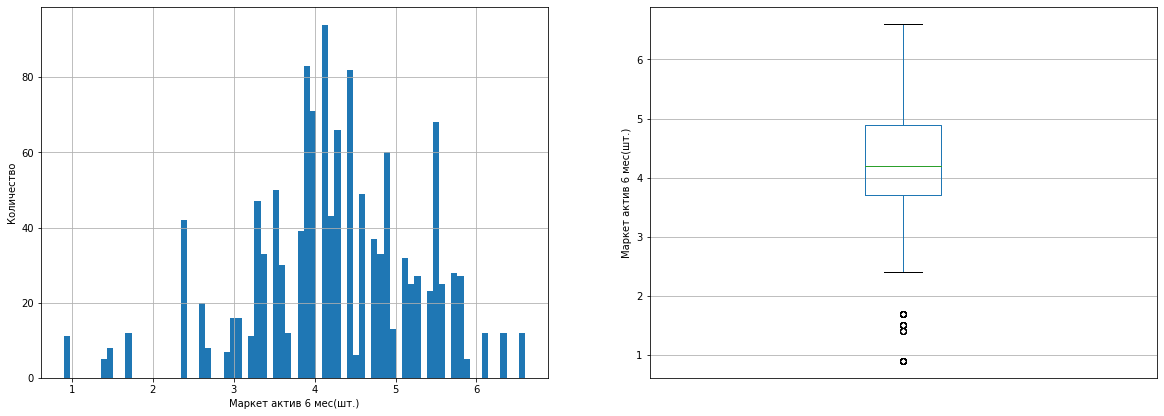

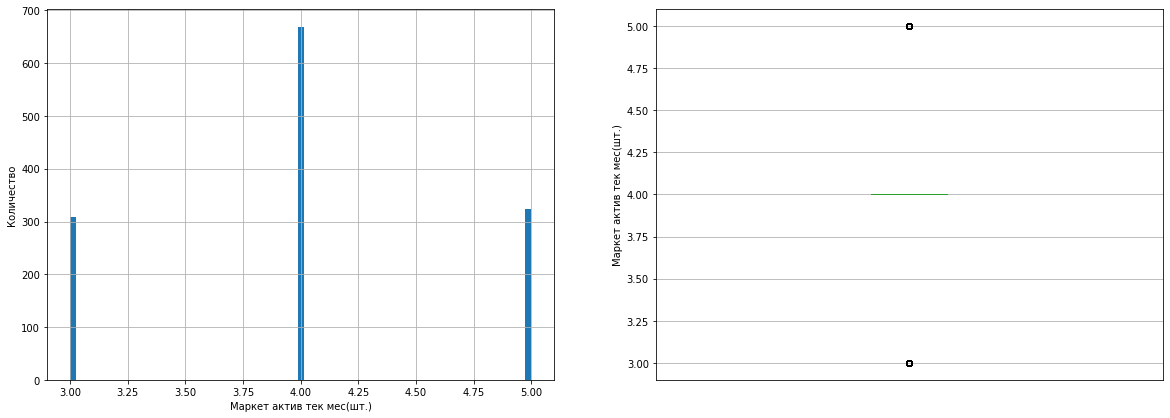

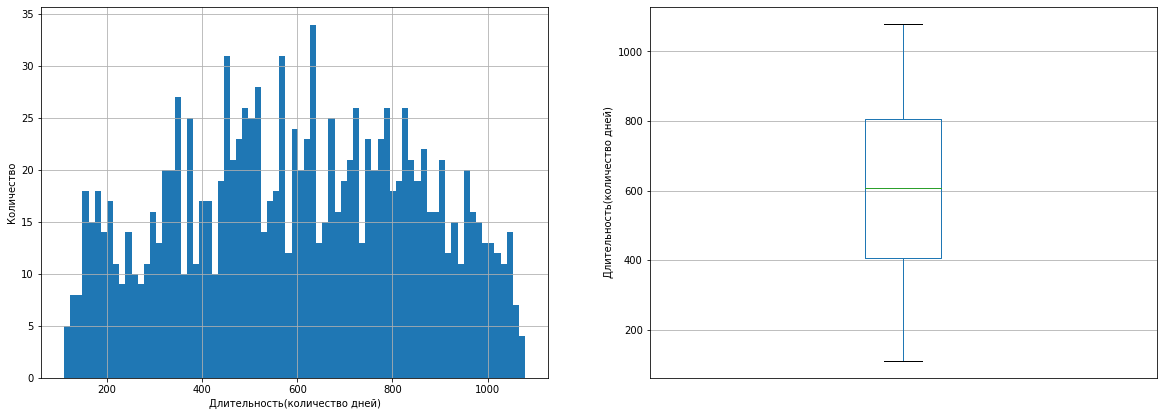

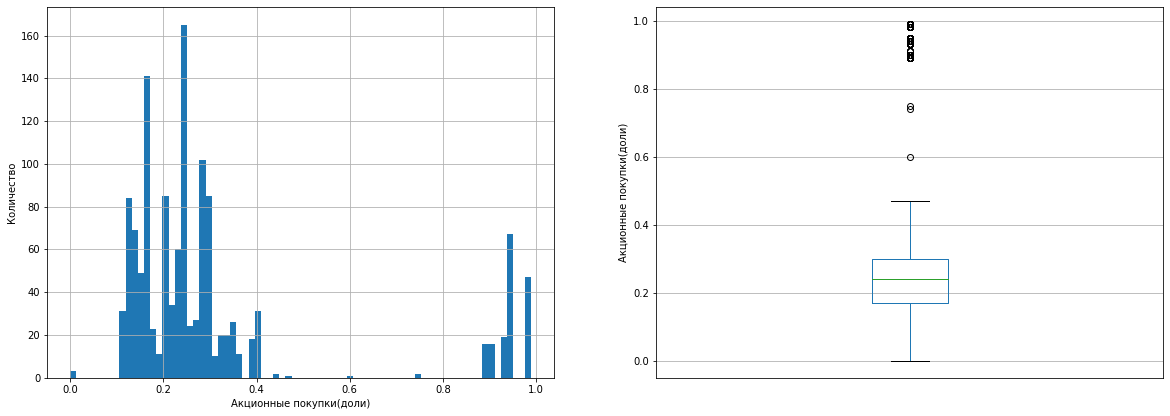

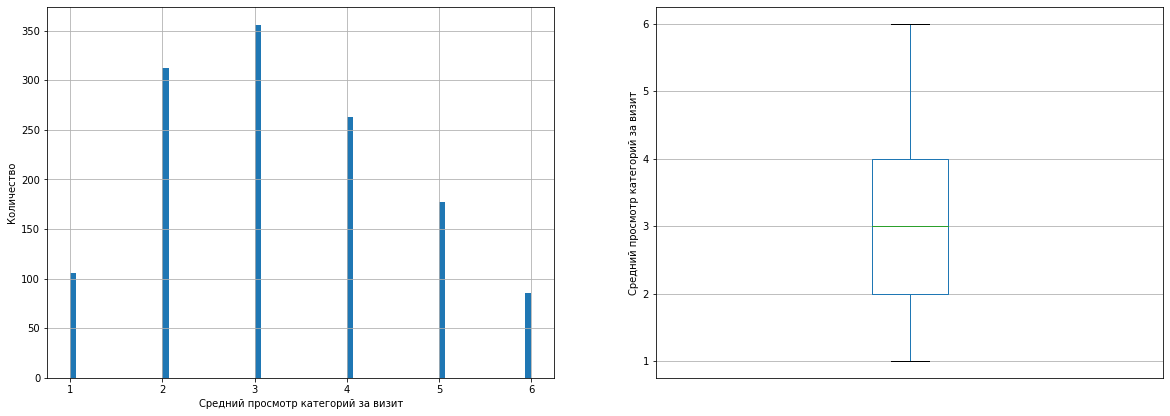

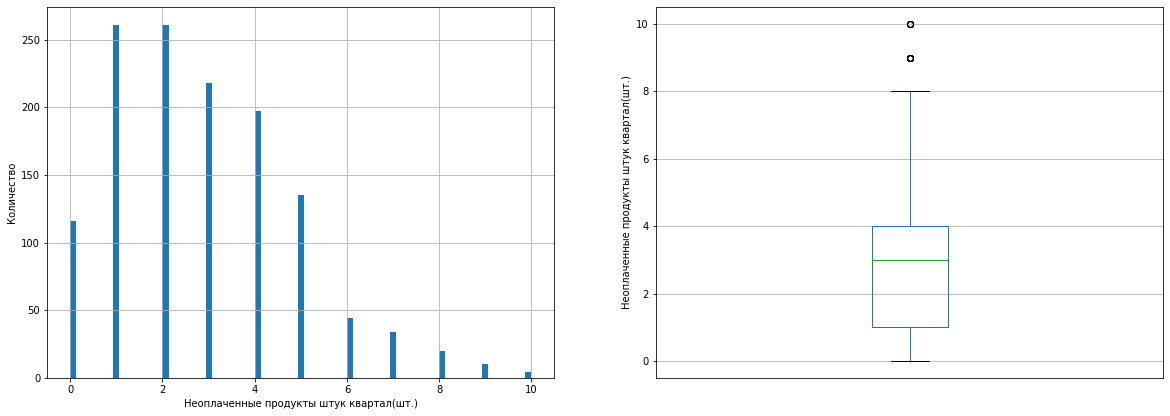

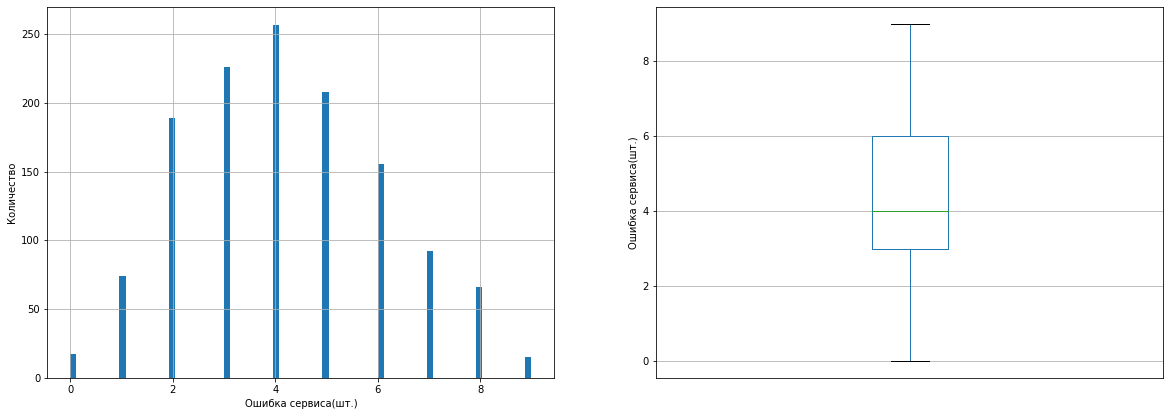

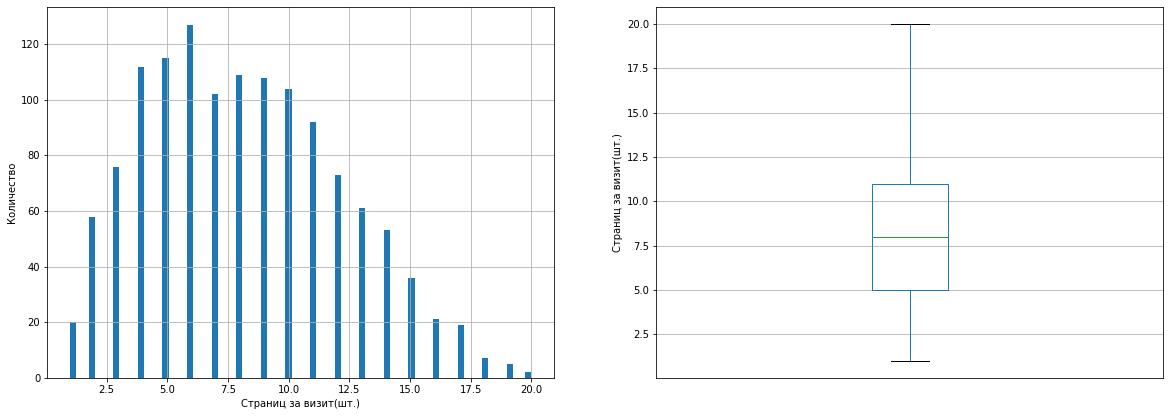

In [43]:
counting_param(market_file, market_file_list, market_file_title_list,'Количество')

Из представленных гистограмм и диаграмм размахов видно следующее: выбросы в данных есть, но не везде; некоторые столбцы "чисты" - то есть там нет выбросов. 

Нужно рассмотреть выбросы в столбцах `'маркет_актив_6_мес'`, `'акционные_покупки'` и `'неоплаченные_продукты_штук_квартал'`, а после принимать решение об их удалении или нет. Выбросов в столбце `'маркет_актив_тек_мес'` много, это видно; однако это количество маркетинговых коммуникаций в текущем месяце, удалять эти данные не стоит, так как из гистограммы видно, что данные распределены между отрезком целых чисел от 3 до 5 включительно и просто говорят о количестве.

Подсчитаем количество выбросов в каждом датафрейме, чтобы понять, что с ними делать: 

In [44]:
print('Количество выбросов в столбце "маркет_актив_6_мес":', market_file.query('маркет_актив_6_мес < 2')['id'].count(),
     '\nОтношение количества выбросов к общему количеству данных в датафрейме:', round(market_file.query('маркет_актив_6_мес < 2')['id'].count()*100/len(market_file),3),'%')
print('Количество выбросов в столбце "акционные_покупки":', market_file.query('акционные_покупки > 0.57')['id'].count(),
     '\nОтношение количества выбросов к общему количеству данных в датафрейме:', round(market_file.query('акционные_покупки > 0.57')['id'].count()*100/len(market_file),3),'%')
print('Количество выбросов в столбце "неоплаченные_продукты_штук_квартал":', market_file.query('неоплаченные_продукты_штук_квартал > 8')['id'].count(),
     '\nОтношение количества выбросов к общему количеству данных в датафрейме:', round(market_file.query('неоплаченные_продукты_штук_квартал > 8')['id'].count()*100/len(market_file),3),'%')

Количество выбросов в столбце "маркет_актив_6_мес": 36 
Отношение количества выбросов к общему количеству данных в датафрейме: 2.769 %
Количество выбросов в столбце "акционные_покупки": 168 
Отношение количества выбросов к общему количеству данных в датафрейме: 12.923 %
Количество выбросов в столбце "неоплаченные_продукты_штук_квартал": 14 
Отношение количества выбросов к общему количеству данных в датафрейме: 1.077 %


Из представленного количества и процентного соотношения, графиков гистограмм можно говорить о следующем: выбросов в столбце `'маркет_актив_6_мес'` и `'неоплаченные_продукты_штук_квартал'` крайне мало - 2.8% и всего 1% соответственно, а в столбце `'акционные_покупки'` составляют значительную часть данных - около 13%. Говорить об их удалении крайне трудно, так как наши грфики распределений имеют разный вид и их нельзя отнести к какому-то известному или существующему, и из-за этого полагаться на квантили опасно, так как мы можем рисковать тем, что удалим необходимые для нас данные.

Поэтому примем решение оставить все данные в том виде, в котором мы их и изучили, то есть не будет проводить **удаление выбросов**.

Снова вызовем функцию `counting_param()`, но уже к каждому столбцу датафрейма `market_money`, содержащим количественные переменные: 

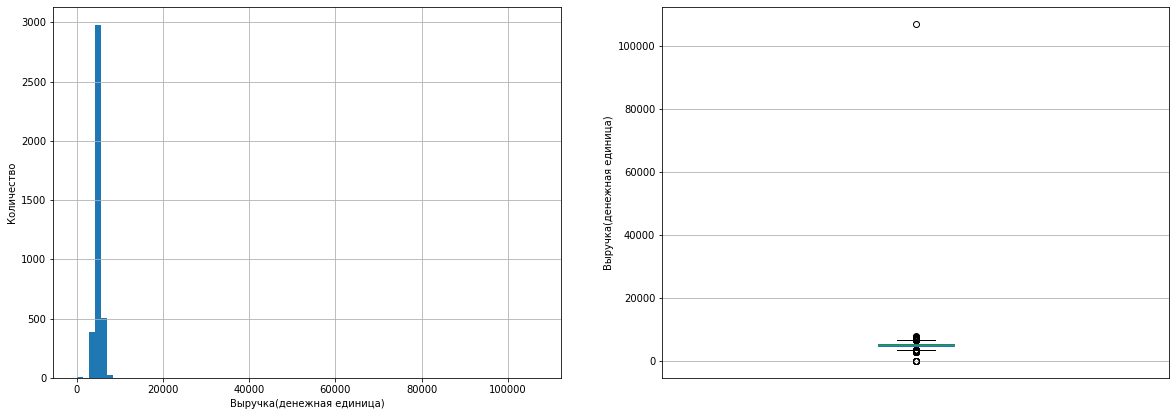

In [45]:
counting_param(market_money, ['выручка'], ['Выручка(денежная единица)'],'Количество')

На диаграмме размаха очевиден выброс в более 100000 д.е., поэтому сделаем срез данных менее 20000 и снова вызовем функцию `counting_param()`:

In [46]:
market_money = market_money.query('выручка < 20000')

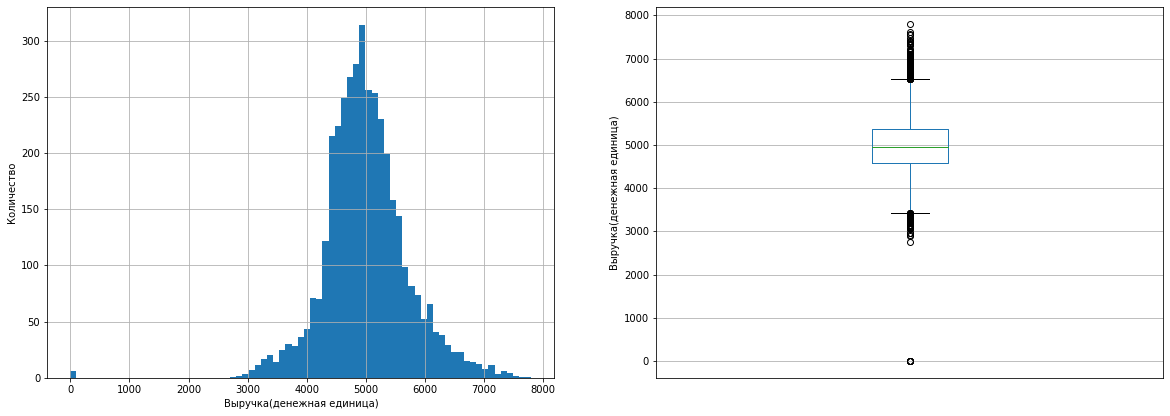

In [47]:
counting_param(market_money, ['выручка'], ['Выручка(денежная единица)'],'Количество')

Из представленного распределения и диаграммы размаха можно говорить о следующем: очевидно, что выбросов в столбце `'выручка'` много, поэтому удалять такое количество данных **не будем**, так как дальнейшее исследование и создание модели МО может значительно исказиться.

Снова вызовем функцию `counting_param()`, но уже к каждому столбцу датафрейма `market_time`: 

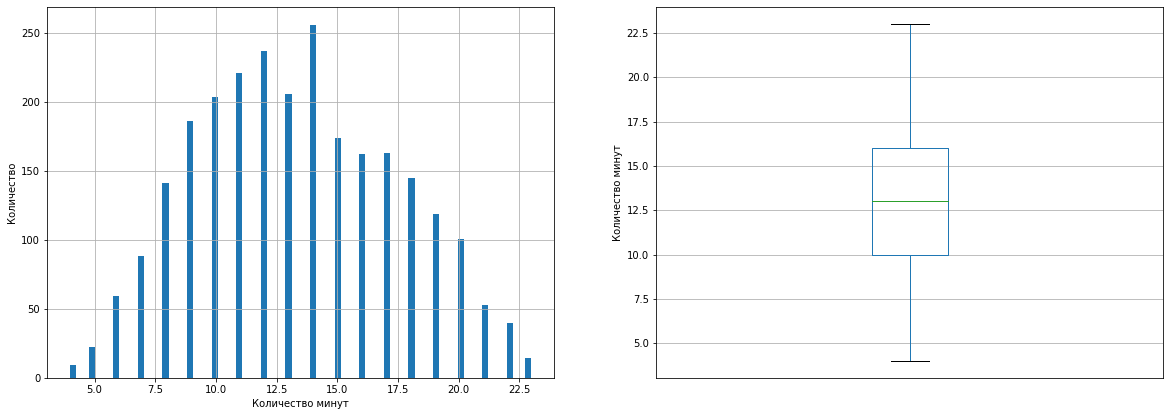

In [48]:
counting_param(market_time, ['минут'], ['Количество минут'],'Количество')

Из представленной гистограммы и диаграммы размаха датафрейма `'market_time'` видно следующее: выбросов в данных нет - что очень хорошо. Также из гистограммы можно говорить о том, что в какой-то степени распределением имеет "нормальный" вид.

Снова вызовем функцию `counting_param()`, но уже к каждому столбцу датафрейма `money`: 

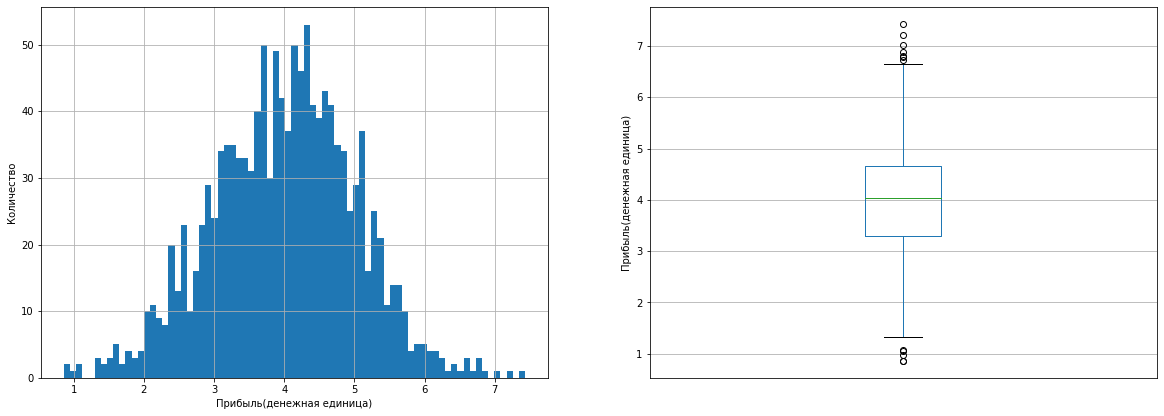

In [49]:
counting_param(money, ['прибыль'], ['Прибыль(денежная единица)'],'Количество')

Из представленной гистограммы и диаграммы размаха видно следующее: выбросы в данных есть, но их число небольшое, поэтому оставим их, так как они маловероятно смогут исказить результат исследования.

### Рассмотрим категориальные переменные

Для того чтобы подсчитать количество значений в конкретном столбце категориальных переменных, воспользуемся методом `.value_counts()`; после для наглядности выведем круговую диаграмму этих значений.

Рассмотрим датафреймы с малым числом таких столбцов -  `market_money`,  `market_time`:

предыдущий_месяц       1300
препредыдущий_месяц    1300
текущий_месяц          1299
Name: период, dtype: int64

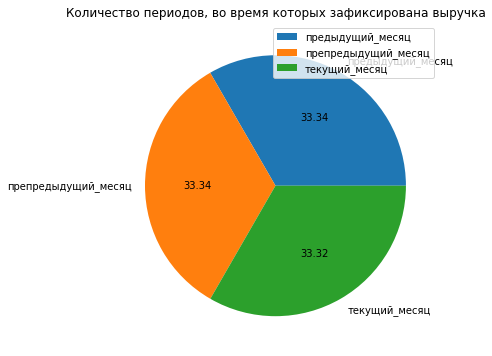

In [50]:
display(market_money['период'].value_counts())
market_money['период'].value_counts().plot(kind='pie', autopct='%.2f', figsize=(8,6))
plt.ylabel(' ')
plt.title('Количество периодов, во время которых зафиксирована выручка')
plt.legend()
plt.show()

предыдущий_месяц    1300
текущий_месяц       1300
Name: период, dtype: int64

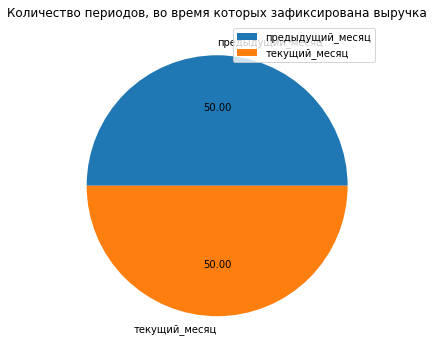

In [51]:
display(market_time['период'].value_counts())
market_time['период'].value_counts().plot(kind='pie', autopct='%.2f', figsize=(8,6))
plt.ylabel(' ')
plt.title('Количество периодов, во время которых зафиксирована выручка')
plt.legend()
plt.show()

Из представленных круговых диаграмм можно говорить следующее:
- в датафрейме `'market_money'` данные 'препредыдущий_месяц' - 'предыдущий_месяц' - 'текущий_месяц' распределены по отношению 1:1:1 соответственно, то есть по 1/3 данных на каждый месяц
- в датафрейме `'market_time'` данные 'предыдущий_месяц' - 'текущий_месяц' распределены пополам, то есть 50/50

Для оптимизации напишем функцию `dataframe_diagram()`, которая будет строить и выводить круговые диаграммы; в функцию будем передавать датафрейм, список необходимых столбцов и список заголовочных названий графиков: 

In [52]:
def dataframe_diagram(dataframe, data_list, title_list):
    for i,j in zip(data_list,title_list):
        dataframe[i].value_counts().sort_values(ascending=True).plot(kind='barh',  figsize=(8,6))
        plt.ylabel(' ')
        plt.title(j)
        plt.legend()
        plt.show()
        print(dataframe[i].value_counts())

Применим функцию `dataframe_diagram()` к категориальным данным датафрейма `market_file `:

In [53]:
market_file_cat_list = ['Количество классов покупательской активности', 'Количество типов сервиса', 
                        'Количество разрешений о сообщении', 'Количество популярных категорий']

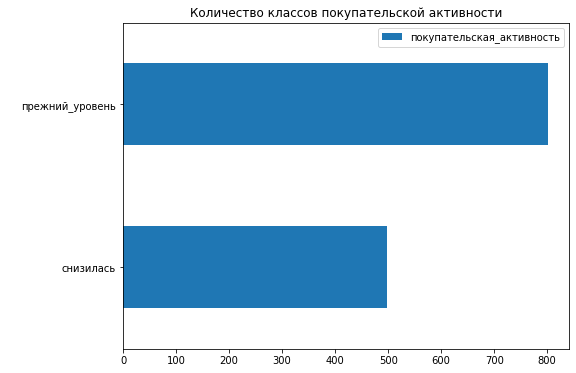

прежний_уровень    802
снизилась          498
Name: покупательская_активность, dtype: int64


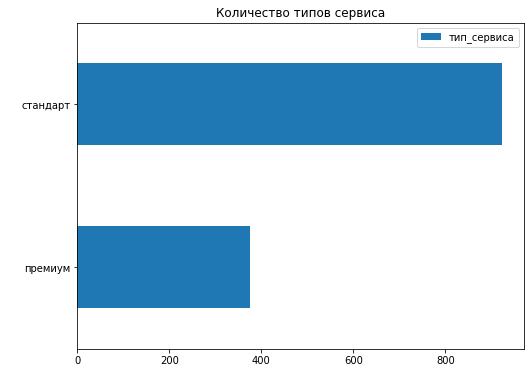

стандарт    924
премиум     376
Name: тип_сервиса, dtype: int64


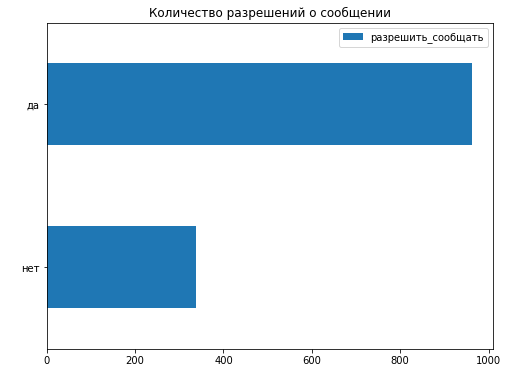

да     962
нет    338
Name: разрешить_сообщать, dtype: int64


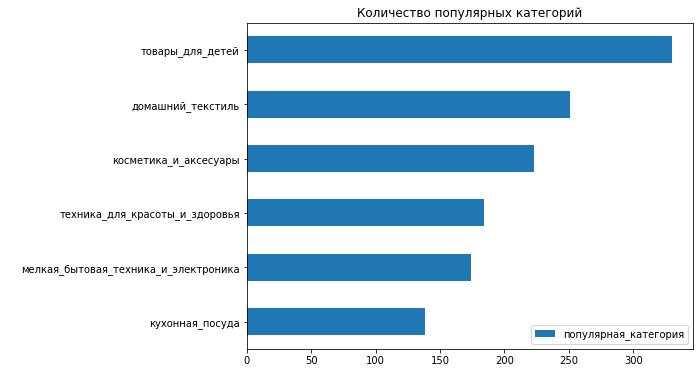

товары_для_детей                        330
домашний_текстиль                       251
косметика_и_аксесуары                   223
техника_для_красоты_и_здоровья          184
мелкая_бытовая_техника_и_электроника    174
кухонная_посуда                         138
Name: популярная_категория, dtype: int64


In [54]:
dataframe_diagram(market_file, market_file.drop(columns = market_file.describe().columns).columns, market_file_cat_list)

In [55]:
print('Процентное соотношение прежнего уровня покупательской активности к общему числу данных:', 
      round(market_file['покупательская_активность'].value_counts().sort_values(ascending=True)[1]*100/len(market_file), 2),'%')
print('Процентное соотношение типа сервиса (стандарт) к общему числу данных:', 
      round(market_file['тип_сервиса'].value_counts().sort_values(ascending=True)[1]*100/len(market_file), 2),'%')
print('Процентное соотношение разрешения (да) на сообщение информации о дополнительных предложениях к общему числу данных:', 
      round(market_file['разрешить_сообщать'].value_counts().sort_values(ascending=True)[1]*100/len(market_file), 2),'%')
print('Процентное соотношение 3-ки популярных категорий от общего числа данных:\nтовары_для_детей:', 
      round(market_file['популярная_категория'].value_counts().sort_values(ascending=True)[5]*100/len(market_file), 2),'%\nдомашний_текстиль:',
      round(market_file['популярная_категория'].value_counts().sort_values(ascending=True)[4]*100/len(market_file), 2),'%\nкосметика_и_аксесуары:',
      round(market_file['популярная_категория'].value_counts().sort_values(ascending=True)[3]*100/len(market_file), 2),'%')

Процентное соотношение прежнего уровня покупательской активности к общему числу данных: 61.69 %
Процентное соотношение типа сервиса (стандарт) к общему числу данных: 71.08 %
Процентное соотношение разрешения (да) на сообщение информации о дополнительных предложениях к общему числу данных: 74.0 %
Процентное соотношение 3-ки популярных категорий от общего числа данных:
товары_для_детей: 25.38 %
домашний_текстиль: 19.31 %
косметика_и_аксесуары: 17.15 %


Из полученных результатов можно говорить следующее:
- класс покупательской активности остался на прежнем уровне около 62% пользователей;
- уровень сервиса у более 70% пользователей является 'стандарт'
- около 74% покупателей согласны получать информацию о дополнительных предложениях о товаре
- наиболее популярными категориями для покупки товаров у покупателя являются: 'товары для детей' (25.38%), 'домашний текстиль' (19.31%) и 'косметика и аксесуары' (17.15%)

### Отберем клиентов с покупательской активностью не менее трёх месяцев

Для того чтобы отобрать клиентов с покупательской активностью не менее трёх месяцев, необходимо будет рассмотреть следующие столбцы с данными:
- `'выручка'`: сумма выручки за период; значение, которое показывает, сколько покупатель всего потратил за период взаимодействия с сайтом
- `'период'`:  название периода, во время которого зафиксирована выручка. 

Для этого рассмотрим датафрейм `market_money`. Так как нам нужны активные пользователи, то определим `id` покупателей, которые делали покупки, хотя бы один раз на последний месяц и запишем найденные `id` в переменную `active_users_id`:

In [56]:
active_users = market_money.pivot_table(index='id', columns='период', values='выручка').reset_index()
active_users['выручка_за_3_месяца'] = (active_users['предыдущий_месяц'] * 
                                       active_users['препредыдущий_месяц'] * active_users['текущий_месяц'])
active_users = active_users.query('выручка_за_3_месяца > 0')
active_users_id = active_users['id'].tolist()

Сравним полученные `id` с основным датафреймом `market_file`, и обновим данные согласно активным пользователям:

In [57]:
market_file['активность'] = market_file['id'].apply(lambda id: True if id in active_users_id else False)

In [58]:
market_file = market_file.query('активность == True')

In [59]:
market_file = market_file.drop(columns='активность')

In [60]:
market_file.head()

,id,покупательская_активность,тип_сервиса,разрешить_сообщать,маркет_актив_6_мес,маркет_актив_тек_мес,длительность,акционные_покупки,популярная_категория,средний_просмотр_категорий_за_визит,неоплаченные_продукты_штук_квартал,ошибка_сервиса,страниц_за_визит
1,215349,снизилась,премиум,да,4.4,4,819,0.75,товары_для_детей,4,4,2,5
2,215350,снизилась,стандарт,нет,4.9,3,539,0.14,домашний_текстиль,5,2,1,5
3,215351,снизилась,стандарт,да,3.2,5,896,0.99,товары_для_детей,5,0,6,4
4,215352,снизилась,стандарт,нет,5.1,3,1064,0.94,товары_для_детей,3,2,3,2
5,215353,снизилась,стандарт,да,3.3,4,762,0.26,домашний_текстиль,4,1,1,4


Из представленных результатов видно, что размеры рассматриваемого датафрейма уменьшились. Теперь можно говорить, что в датафрейме все покупатели *активны не менее трёх месяцев*.

### Сделаем выводы о данных

В результате исследования количественных признаков были получены следующие результаты:
- были проанализированы выбросы во всех датафреймах
- было проведено исследование на удаление или сохранение выбросов в результате которого было принято решение **не удалять** выбросы, так как не все графики имеют нормальное распределение, а у некоторых крайне мало выбросов, что маловероятно повлияет на результаты исследования.

В результате исследования категориальных признаков были получены следующие результаты:
- выручка, которую получил магазин с покупателя, в течение периодов `'препредыдущий_месяц'` - `'предыдущий_месяц'` - `'текущий_месяц'` распределены по отношению 1:1:1 соответственно, то есть по 1/3 данных на каждый месяц
- время (в минутах), которое покупатель провёл на сайте в течение периодов `'предыдущий_месяц'` - `'текущий_месяц'` распределены пополам, то есть 50/50

- класс покупательской активности остался на прежнем уровне около 62% пользователей - это допустимый показатель
- уровень сервиса у более 70% пользователей является `'стандарт'`, это говорит, что основной ориентир  нужно сделать на клиентов уровня `'стандарт'`
- около 74% покупателей согласны получать информацию о дополнительных предложениях о товаре - это может говорить, что данные клиенты могут быть в будущем заинтересованы снова купить у нас товары 
- наиболее популярными категориями для покупки товаров у покупателя являются: `'товары для детей'` (25.34%), `'домашний текстиль'` (19.18%) и `'косметика и аксесуары'` (17.11%) - это означает, что данные товары востребованы чаще других и на них стоит сделать акцент как в продаже, так и во всплывающей рекламе на сайте

Также был проведён анализ по отбору клиентов с покупательской активностью не менее трёх месяцев, в результате которого были отобраны такие покупатели.

## Объединение таблиц


**Объединим данные в один датафрейм**:

Прежде чем объединять датафреймы в один общий, подготовим каждый из них.

Рассмотрим датафрейм `market_money` и создадим его копию, результат которой запишем в `sort_market_money`:

In [61]:
sort_market_money = market_money.copy()
print(sort_market_money.shape)
sort_market_money.head()

(3899, 3)


,id,период,выручка
0,215348,препредыдущий_месяц,0.0
1,215348,текущий_месяц,3293.1
2,215348,предыдущий_месяц,0.0
3,215349,препредыдущий_месяц,4472.0
4,215349,текущий_месяц,4971.6


Теперь с помощью метода `pivot_table()` отсортируем таблицу так, чтобы объединение данных стало легче и понятнее в чтении в дальнейшем, то есть для кажого `'id'` запишем какая выручка была получена в *предыдущем* и *текущем* месяцах:

In [62]:
sort_market_money = sort_market_money.pivot_table(index='id', columns='период', values='выручка').reset_index()

In [63]:
sort_market_money.head()

период,id,предыдущий_месяц,препредыдущий_месяц,текущий_месяц
0,215348,0.0,0.0,3293.1
1,215349,5216.0,4472.0,4971.6
2,215350,5457.5,4826.0,5058.4
3,215351,6158.0,4793.0,6610.4
4,215352,5807.5,4594.0,5872.5


In [64]:
# переименнуем названия столбцов и выведем новый размеры 
sort_market_money.columns = ['id', 'выручка_предыдущий_месяц', 'выручка_препредыдущий_месяц', 'выручка_текущий_месяц']
sort_market_money.shape

(1300, 4)

Теперь проделаем аналогичные действия для датафрейма `market_time`:

In [65]:
sort_market_time = market_time.copy()

In [66]:
print(sort_market_time.shape)
sort_market_time.head()

(2600, 3)


,id,период,минут
0,215348,текущий_месяц,14
1,215348,предыдущий_месяц,13
2,215349,текущий_месяц,10
3,215349,предыдущий_месяц,12
4,215350,текущий_месяц,13


In [67]:
# группировка методом pivot_table()
sort_market_time = sort_market_time.pivot_table(index='id', columns='период', values='минут').reset_index()

In [68]:
sort_market_time.head()

период,id,предыдущий_месяц,текущий_месяц
0,215348,13,14
1,215349,12,10
2,215350,8,13
3,215351,11,13
4,215352,8,11


In [69]:
# переименнуем названия столбцов и выведем новый размеры 
sort_market_time.columns = ['id', 'минут_предыдущий_месяц', 'минут_текущий_месяц']
sort_market_time.shape

(1300, 3)

Была успешно проведена необходимая обработка датафреймов перед общим объединением.

Теперь для объединения данных воспользуемся методом `merge()` и создадим датафрейм `full_data`, куда запишем объединенную информацию о датафреймах `market_file`, `sort_market_money` и `sort_market_time`. После этого выведем первые строки объёдинённого датафрейма.

In [70]:
# объединение с учетом параметра how='inner', так как важно объединить данные с теми 'id', которые действительно присутствуют
# в датафреймах
full_data = market_file.merge(sort_market_money, on='id', how='inner')
full_data = full_data.merge(sort_market_time, on='id', how='inner')

In [71]:
full_data.head()

,id,покупательская_активность,тип_сервиса,разрешить_сообщать,маркет_актив_6_мес,маркет_актив_тек_мес,длительность,акционные_покупки,популярная_категория,средний_просмотр_категорий_за_визит,неоплаченные_продукты_штук_квартал,ошибка_сервиса,страниц_за_визит,выручка_предыдущий_месяц,выручка_препредыдущий_месяц,выручка_текущий_месяц,минут_предыдущий_месяц,минут_текущий_месяц
0,215349,снизилась,премиум,да,4.4,4,819,0.75,товары_для_детей,4,4,2,5,5216.0,4472.0,4971.6,12,10
1,215350,снизилась,стандарт,нет,4.9,3,539,0.14,домашний_текстиль,5,2,1,5,5457.5,4826.0,5058.4,8,13
2,215351,снизилась,стандарт,да,3.2,5,896,0.99,товары_для_детей,5,0,6,4,6158.0,4793.0,6610.4,11,13
3,215352,снизилась,стандарт,нет,5.1,3,1064,0.94,товары_для_детей,3,2,3,2,5807.5,4594.0,5872.5,8,11
4,215353,снизилась,стандарт,да,3.3,4,762,0.26,домашний_текстиль,4,1,1,4,4738.5,5124.0,5388.5,10,10


Посмотрим на размеры полученного датафрейма:

In [72]:
full_data.shape

(1296, 18)

В итоговом датафрейме 1296 строк с данными, в отличие от `sort_market_money` и `sort_market_time`. Это связано с тем, что в датафрейме `market_file` такое количество строк и применение параметра `how='inner'`; если бы этого не было сделано, то было бы 1300 строк, но тогда были бы получены значения `NaN`, так какой-то части данных уже не было бы в датафрейме `market_file`.

Выведем размеры датафрейма `market_file`, чтобы убедиться:

In [73]:
market_file.shape

(1296, 13)

**Промежуточный вывод:**

В результате объединения таблиц были выполнены следующие шаги:
- сгруппированы по `'id'` методом `pivot_table()` данные датафреймов `market_money` и `market_time`
- методом `merge()` были объеденены датафреймы и записаны в `full_data`
- объединение происходило с учётом тех данных, которые находились в датафрейме `market_file`

## Корреляционный анализ

**Проведём корреляционный анализ признаков в датасете `full_data`**

Изучим взаимосвязь между признаками в датафрейме `full_data` - рассчитаем коэффициенты корреляции между всеми признаками. Для этого воспользуемся методом `.corr()`, который возвращает коэффициент корреляции; перед этим удалим столбец `'id'`, так как он лишь показывает уникальный идентификатор покупателя, который никак не связан с остальными столбцами. Для анализа корреляции данных в метод `.corr()` передадим `'spearman'` - коэффициент Спирмена, так как не все признаки имеют "нормальное" распределение:

In [74]:
full_data.drop(columns='id').corr('spearman')

,маркет_актив_6_мес,маркет_актив_тек_мес,длительность,акционные_покупки,средний_просмотр_категорий_за_визит,неоплаченные_продукты_штук_квартал,ошибка_сервиса,страниц_за_визит,выручка_предыдущий_месяц,выручка_препредыдущий_месяц,выручка_текущий_месяц,минут_предыдущий_месяц,минут_текущий_месяц
маркет_актив_6_мес,1.000000,0.061741,-0.044445,-0.276590,0.185013,-0.135045,0.038643,0.319872,-0.003642,0.234728,0.002093,0.273727,0.226968
маркет_актив_тек_мес,0.061741,1.000000,-0.131967,0.033099,-0.025167,0.061747,0.087343,0.003143,-0.027088,-0.039437,-0.011782,0.013535,-0.063051
длительность,-0.044445,-0.131967,1.000000,0.029045,-0.043154,-0.108787,0.103562,-0.034495,0.013537,-0.039301,0.015002,-0.123940,0.083048
акционные_покупки,-0.276590,0.033099,0.029045,1.000000,-0.203401,0.198307,-0.051593,-0.370860,0.005184,-0.269087,0.022255,-0.332548,-0.275313
средний_просмотр_категорий_за_визит,0.185013,-0.025167,-0.043154,-0.203401,1.000000,-0.251559,0.010034,0.267479,-0.049460,0.149742,-0.070716,0.148279,0.233369
неоплаченные_продукты_штук_квартал,-0.135045,0.061747,-0.108787,0.198307,-0.251559,1.000000,-0.098582,-0.165412,0.033434,-0.249293,0.061178,-0.183575,-0.214699
ошибка_сервиса,0.038643,0.087343,0.103562,-0.051593,0.010034,-0.098582,1.000000,0.104482,0.035476,0.090152,0.040477,0.196009,0.078074
страниц_за_визит,0.319872,0.003143,-0.034495,-0.370860,0.267479,-0.165412,0.104482,1.000000,-0.067610,0.311675,-0.049964,0.450760,0.298120
выручка_предыдущий_месяц,-0.003642,-0.027088,0.013537,0.005184,-0.049460,0.033434,0.035476,-0.067610,1.000000,0.308041,0.879097,-0.084215,-0.083214
выручка_препредыдущий_месяц,0.234728,-0.039437,-0.039301,-0.269087,0.149742,-0.249293,0.090152,0.311675,0.308041,1.000000,0.149944,0.348745,0.299783


Чтобы было проще работать с получившейся матрицей корреляции - построим тепловую карту; применим метод `heatmap` из библиотеки `seaborn`; первым аргументом передадим нашу матрицу, после зададим параметр `annot = True` -  для отображения коэффициентов на карте, и `fmt='.3f'` - чтобы оставить только три знака после запятой у коэффициентов:

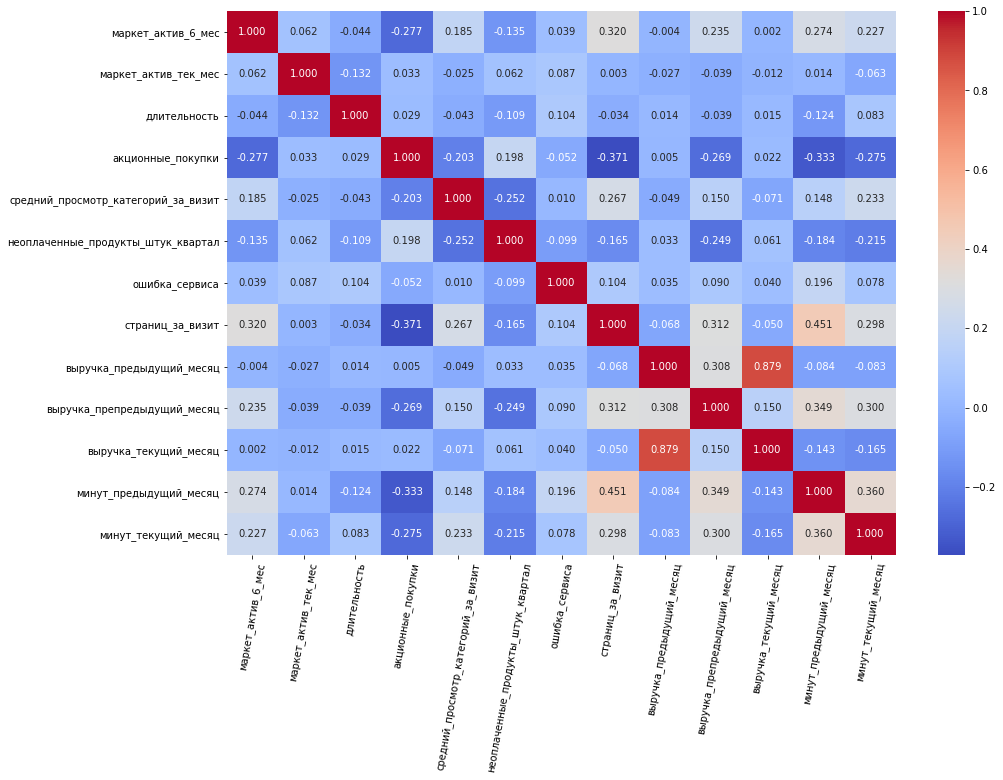

In [75]:
plt.figure(figsize=(15, 10))
sns.heatmap(full_data.drop(columns='id').corr('spearman'), annot=True, fmt='.3f', cmap='coolwarm')
plt.xticks(rotation=80)
plt.show()

На тепловой карте удобно представлены результаты, по которым можно провести анализ. Согласно *шкале Чеддока* можно говорить о следующее: почти все величины не коррелируют между собой, однако наблюдается **умеренная** связь между количественными признаками `минут_предыдущий_месяц` и `страниц_за_визит`, а также **высокая** - между `выручка_предыдущий_месяц` и `выручка_текущий_месяц`.

Рассмотрим график рассеивания `scatterplot` между признаками, имеющими высокую связь:

(3500.0, 6000.0)

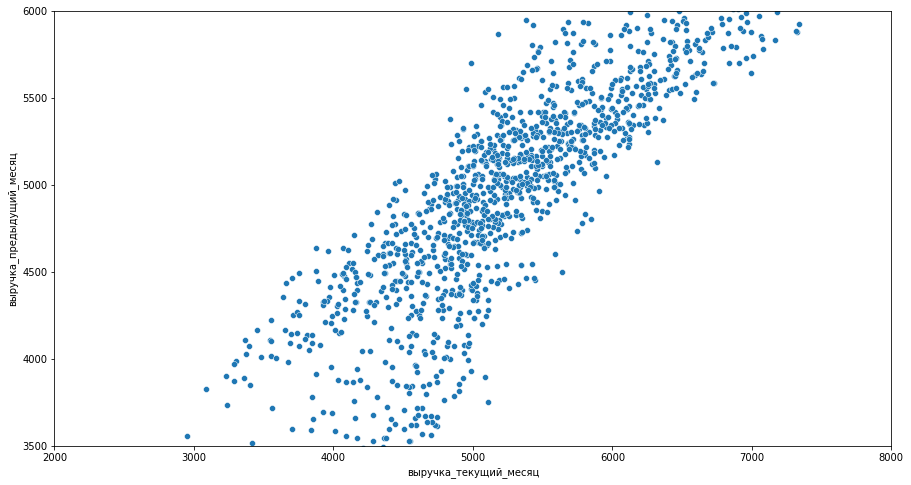

In [76]:
plt.figure(figsize=(15, 8))
sns.scatterplot(data=full_data, x='выручка_текущий_месяц', y='выручка_предыдущий_месяц', palette='bright')
plt.xlim(2000,8000)
plt.ylim(3500,6000)

Из графика можно сказать, что данные скорее представлены близко по группам друг к другу, и говорить о мультиколлениарности тут нельзя, так как невозможно даже однозначно точно провести прямую, так как она может быть каждый раз под разными углами.

Также стоит упомянуть, что данные параметры - `выручка_предыдущий_месяц` и `выручка_текущий_месяц` - это независимые параметры; между ними нет ни явной, ни причинно-следственной связи и коэффициент корреляции равный или более 0.85, поэтому и говорить о мультиколлениарности тут нельзя.

В связи с этим никакие признаки из датафрейма удалять не нужно.

**Промежуточный вывод:**

В результате корреляционного анализ данных было проделано следующее:
- построили тепловую карту матрицы корреляционных значений и проанализировали 
- сделали выводы о взаимосвязи признаков
- построили диаграмму рассеяния для признаков `выручка_предыдущий_месяц` и `выручка_текущий_месяц`
- проанализировали графики и определили, что между признаками `выручка_предыдущий_месяц`-`выручка_текущий_месяц` нет мультиколлениарности, так как между ними нет ни явной связи, ни причинно-следственной связи, ни коэффициента корреляции равного или более 0.85    

## Использование пайплайнов

Применим изученные модели, а также воспользуемся пайплайнами.


Во время подготовки данных воспользуемся ColumnTransformer.

Количественные и категориальные признаки обработаем в пайплайне раздельно. Для кодирования категориальных признаков будем использовать два кодировщика, для масштабирования количественных — два скейлера. Для каждой модели можно подготовим данные с разным кодированием и масштабированием.

Прежде чем переходить к кодированию и масштабированию, рассмотрим столбец `'покупательская_активность'` в `full_data`. Так как он имеет строковые данные, а именно этот столбец является целевым, то с ним трудно будет работать в таком виде, поэтому закодируем его следующим образом: `1` - покупательская активность *`снизилась`*, `0` - покупательская активность *`на прежнем уровне`*.

In [77]:
target_data = pd.DataFrame(full_data['покупательская_активность'])
target_data['код_покупательская_активность'] = target_data['покупательская_активность'].apply(lambda x: 1 if (x == 'снизилась') else 0)
target_data.head()

,покупательская_активность,код_покупательская_активность
0,снизилась,1
1,снизилась,1
2,снизилась,1
3,снизилась,1
4,снизилась,1


Теперь приступим к создании пайплайнов и определению лучшей модели:

In [78]:
# создание констант
RANDOM_STATE = 42
TEST_SIZE = 0.25

# Деление и сохранение на тренировочную и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(full_data.drop(['id','покупательская_активность'], axis=1), 
                                                    target_data['код_покупательская_активность'], test_size = TEST_SIZE, 
                                                    random_state = RANDOM_STATE, 
                                                    stratify = target_data['код_покупательская_активность'])

# Размеры тренировочных и тестовых выборкок
X_train.shape, X_test.shape

((972, 16), (324, 16))

In [79]:
full_data.drop(['id','покупательская_активность'], axis=1)

,тип_сервиса,разрешить_сообщать,маркет_актив_6_мес,маркет_актив_тек_мес,длительность,акционные_покупки,популярная_категория,средний_просмотр_категорий_за_визит,неоплаченные_продукты_штук_квартал,ошибка_сервиса,страниц_за_визит,выручка_предыдущий_месяц,выручка_препредыдущий_месяц,выручка_текущий_месяц,минут_предыдущий_месяц,минут_текущий_месяц
0,премиум,да,4.4,4,819,0.75,товары_для_детей,4,4,2,5,5216.0,4472.0,4971.6,12,10
1,стандарт,нет,4.9,3,539,0.14,домашний_текстиль,5,2,1,5,5457.5,4826.0,5058.4,8,13
2,стандарт,да,3.2,5,896,0.99,товары_для_детей,5,0,6,4,6158.0,4793.0,6610.4,11,13
3,стандарт,нет,5.1,3,1064,0.94,товары_для_детей,3,2,3,2,5807.5,4594.0,5872.5,8,11
4,стандарт,да,3.3,4,762,0.26,домашний_текстиль,4,1,1,4,4738.5,5124.0,5388.5,10,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1291,стандарт,да,6.6,3,318,0.24,техника_для_красоты_и_здоровья,5,3,3,11,3664.0,4704.0,4741.7,14,7
1292,стандарт,нет,5.1,4,454,0.21,домашний_текстиль,6,2,3,9,4729.0,5299.0,5353.0,12,11
1293,стандарт,да,4.1,3,586,0.20,домашний_текстиль,3,2,5,7,5160.0,5334.0,5139.2,12,18
1294,стандарт,да,6.3,5,645,0.12,техника_для_красоты_и_здоровья,3,3,5,7,4923.0,4725.0,5224.6,18,7


In [80]:
# создаём списки с названиями признаков
ohe_columns = ['тип_сервиса', 'разрешить_сообщать', 'популярная_категория']
ord_columns = ['маркет_актив_тек_мес']
num_columns = ['маркет_актив_6_мес',  'длительность', 'акционные_покупки', 
               'средний_просмотр_категорий_за_визит', 'неоплаченные_продукты_штук_квартал', 'ошибка_сервиса', 
               'страниц_за_визит', 'выручка_предыдущий_месяц', 'выручка_препредыдущий_месяц', 'выручка_текущий_месяц', 'минут_предыдущий_месяц', 
               'минут_текущий_месяц']

In [81]:
# создаём пайплайн для подготовки признаков из списка ohe_columns: заполнение пропусков и OHE-кодирование
# SimpleImputer + OHE
ohe_pipe = Pipeline(
    [('simpleImputer_ohe', SimpleImputer(missing_values=np.nan, strategy='most_frequent')),
     ('ohe', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False))
    ]
    )

In [82]:
# создаём пайплайн для подготовки признаков из списка ord_columns: заполнение пропусков и Ordinal-кодирование
# SimpleImputer + OE
ord_pipe = Pipeline(
    [('simpleImputer_before_ord', SimpleImputer(missing_values=np.nan, strategy='most_frequent')),
     ('ord',  OrdinalEncoder(
                categories=[
                    [3, 4, 5], 
                ], 
                handle_unknown='use_encoded_value', unknown_value=np.nan
            )
        ),
     ('simpleImputer_after_ord', SimpleImputer(missing_values=np.nan, strategy='most_frequent'))
    ]
)

In [83]:
# создаём общий пайплайн для подготовки данных
data_preprocessor = ColumnTransformer(
    [('ohe', ohe_pipe, ohe_columns),
     ('ord', ord_pipe, ord_columns),
     ('num', MinMaxScaler(), num_columns)
    ], 
    remainder='passthrough'
)

In [84]:
# создаём итоговый пайплайн: подготовка данных и модель
pipe_final = Pipeline([
    ('preprocessor', data_preprocessor),
    ('models', DecisionTreeClassifier(random_state=RANDOM_STATE))
])

Пайплайн был успешно создан. Теперь с его помощью найдём лучшую модель. 

Обучим четыре модели: KNeighborsClassifier(), DecisionTreeClassifier(), LogisticRegression() и  SVC(). Для каждой из них подберем как минимум один гиперпараметр.

Создадим `param_grid`, который представляет собой список словарей для различных моделей, и зададим в словаре для каждой модели свои гиперпараметры:
- словарь для модели DecisionTreeClassifier(): `max_depth` и `max_features` помогают контролировать сложность модели и предотвратить переобучение масштабирование числовых признаков может улучшить производительность модели, особенно если признаки имеют разные масштабы
- словарь для модели KNeighborsClassifier(): `n_neighbors` определяет, сколько соседей будут учитываться при классификации; это важный параметр для модели KNN масштабирование числовых признаков важно для KNN, так как модель основана на расстояниях между точками данных
- словарь для модели SVC(): `kernel` определяет тип преобразования данных, что может значительно влиять на производительность модели
- словарь для модели LogisticRegression(): `C` контролирует степень регуляризации, что помогает предотвратить переобучение масштабирование числовых признаков также как и для других моделей важно

In [85]:
# Параметры для поиска
param_grid = [
    # словарь для модели DecisionTreeClassifier()
    {
        'models': [DecisionTreeClassifier(random_state=RANDOM_STATE)],
        'models__max_depth': range(2, 5),
        'models__max_features': range(2, 5),
        'preprocessor__num': [StandardScaler(), MinMaxScaler(), 'passthrough']  
    },

    # словарь для модели KNeighborsClassifier() 
    {
        'models': [KNeighborsClassifier()],
        'models__n_neighbors': range(2,5),
        'preprocessor__num': [StandardScaler(), MinMaxScaler(), 'passthrough']   
    },

    # словарь для модели SVC() 
    {
        'models': [SVC(probability=True, random_state=RANDOM_STATE)],
        'models__kernel': ['rbf','sigmoid','poly'],
        'models__C': [0.1, 1, 10],
        'models__gamma': [0.1, 1, 10],
        'preprocessor__num': [StandardScaler(), MinMaxScaler(), 'passthrough']   
    },

    # словарь для модели LogisticRegression()
    {
        'models': [LogisticRegression(
            random_state=RANDOM_STATE, 
            solver='liblinear', 
            penalty='l1'
        )],
        'models__C': range(1,5),
        'preprocessor__num': [StandardScaler(), MinMaxScaler(), 'passthrough']  
    }

]


Теперь инициализируем класс `RandomizedSearchCV()` для для случайного поиска гиперпараметров с учётом ранее созданных параметров и пайплайнов. В качестве метрики, которой будем проводить оценку модели, будем использовать `ROC-AUC`, так как у нас не задача регрессии и другие метрики просто-напросто не подойдут, а для задачи бинарной классификации данная метрика лучше всего подходит для оценивания модели. 

In [86]:
randomized_search = RandomizedSearchCV(
    pipe_final, 
    param_grid, 
    cv=5,
    scoring='roc_auc',
    random_state=RANDOM_STATE,
    n_jobs=-1
)
randomized_search.fit(X_train, y_train)

print('Лучшая модель и её параметры:\n\n', randomized_search.best_estimator_)
print ('Метрика лучшей модели на тренировочной выборке:', randomized_search.best_score_)

Лучшая модель и её параметры:

 Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('ohe',
                                                  Pipeline(steps=[('simpleImputer_ohe',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ohe',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['тип_сервиса',
                                                   'разрешить_сообщать',
                                                   'популярная_категория']),
                        

In [87]:
# проверим работу модели на тестовой выборке
# рассчитаем прогноз на тестовых данных
y_test_pred = randomized_search.predict_proba(X_test) 
y_test_proba = y_test_pred[:,1]
print(f'Метрика ROC-AUC на тестовой выборке: {roc_auc_score(y_test, y_test_proba )}')

Метрика ROC-AUC на тестовой выборке: 0.9143307850988958


Из полученных результатов работы видно, что лучшей моделью была признана модель `SVC()`, с гиперпараметрами `C=0.1`, `gamma=0.1`, `kernel='sigmoid'`. 

Из метрики ROC-AUC, которая проверялась и на тренировочных, и на тестовых данных очевидно, что модель себя очень хорошо показывает и результаты достаточно близки друг к другу - более `89%` и `91%`; это очень хороший результат, поэтому в дальнейшем исследовании будем использовать модель `SVC()`.

**Промежуточный вывод:**

В результате использования пайплайнов было проделано следующее:
- создали несколько пайплайнов и после объединили их в ещё один пайплайн
- создали словари к каждой модели с диапазоном возможных параметров
- нашли наилучшую модель МО из указанных нами, вычислили и вывели на экран метрики лучшей модели на тренировочной выборке, а после метрику ROC-AUC на тестовой выборке

## Анализ важности признаков

### Оценим важность признаков для лучшей модели

Оценим важность признаков для лучшей найденной модели и построим график важности с помощью метода SHAP. 

Сохраним в `random_best_model` лучшую модель, которая была найдена: 

In [88]:
# лучшая модель 
random_best_model = randomized_search.best_estimator_.named_steps['models']

# preprocessor лучшей модели
preprocessor_best_model = randomized_search.best_estimator_['preprocessor']

In [89]:
# подготовка данных с помощью preprocessor_best_model
X_train_preproc = preprocessor_best_model.transform(X_train)
X_test_preproc = preprocessor_best_model.transform(X_test)

In [90]:
# Получение имен признаков после препроцессинга
ohe_columns_bm = preprocessor_best_model.named_transformers_['ohe'].get_feature_names_out(input_features=ohe_columns)
ord_columns_bm = preprocessor_best_model.named_transformers_['ord'].get_feature_names_out(input_features=ord_columns)
num_columns_bm = preprocessor_best_model['num'].get_feature_names_out(num_columns)
columns_name_list = np.concatenate([ohe_columns_bm, ord_columns_bm, num_columns_bm])

In [91]:
# Создание DataFrame с трансформированными данными
X_train_preproc = pd.DataFrame(X_train_preproc, columns=columns_name_list)
X_test_preproc = pd.DataFrame(X_test_preproc, columns=columns_name_list)

In [94]:
random_best_model.fit(X_train_preproc, y_train)

SVC(C=0.1, gamma=0.1, kernel='sigmoid', probability=True, random_state=42)

In [95]:
explainer_1 = shap.Explainer(random_best_model.predict, X_train_preproc)
shap_values_1 = explainer_1(X_test_preproc)


PermutationExplainer explainer: 100%|██████████| 30/30 [00:14<00:00,  2.14it/s]
PermutationExplainer explainer: 31it [00:14,  1.46s/it]                        


PermutationExplainer explainer:  62%|██████▏   | 201/324 [05:50<03:40,  1.79s/it]


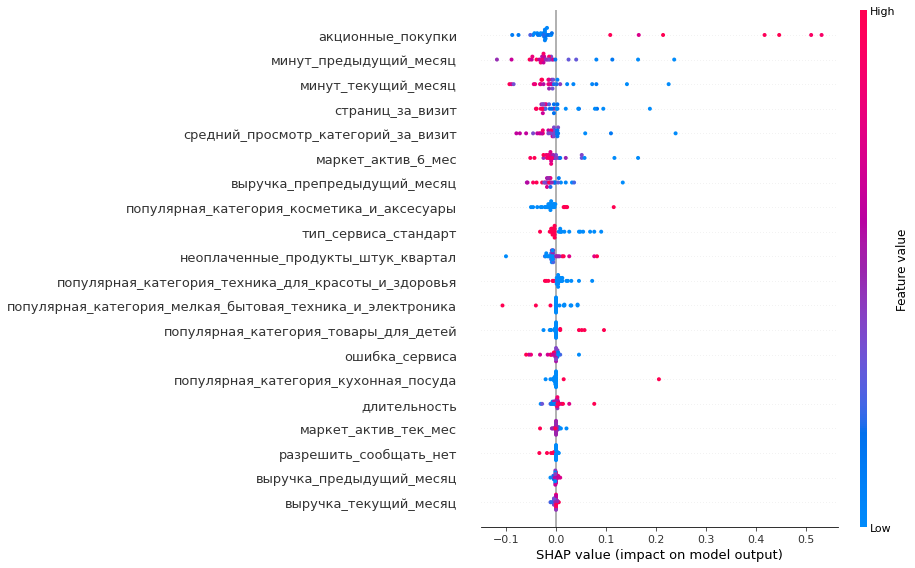

In [96]:
# Построение графика с именами признаков
shap.plots.beeswarm(shap_values_1, max_display=21)

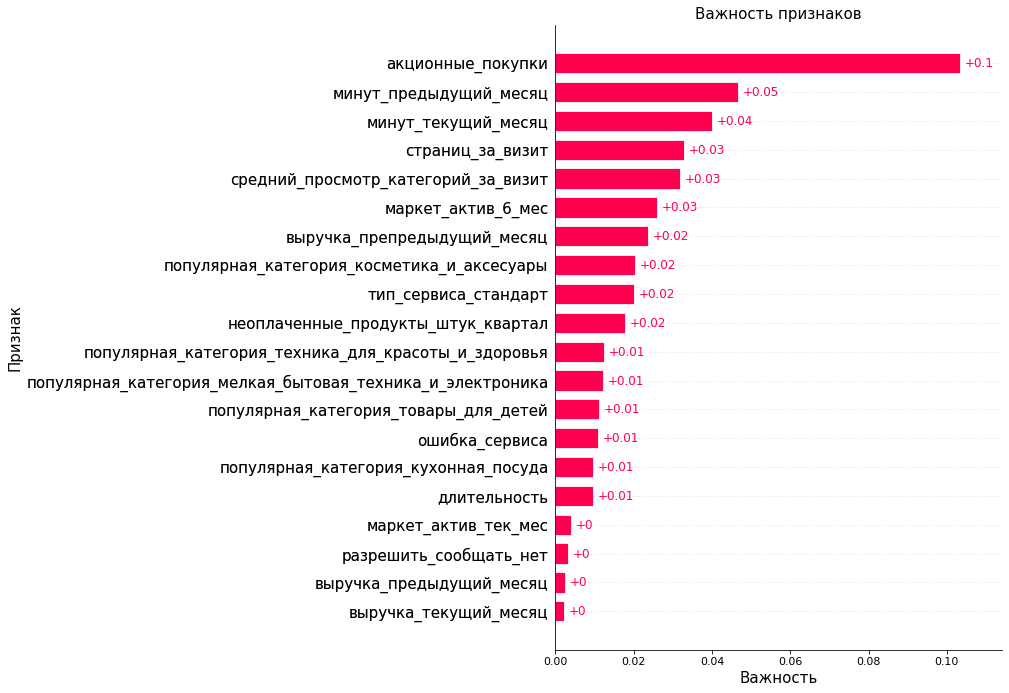

In [97]:
shap.plots.bar(shap_values_1, max_display=21, show=False)
plt.yticks(fontsize=15)
plt.xlabel('Важность', fontsize=15)
plt.ylabel('Признак', fontsize=15)
plt.title('Важность признаков', fontsize=15);

Из результатов графика можно сказать следующее:
- признаки, расположенные в верхней части графика, имеют наибольшее влияние на предсказания модели, а в нижней части - меньшее влияние
- положительные значения указывают на то, что признак увеличивает предсказание модели, а отрицательные значения - признак уменьшает предсказание модели
- красные точки (высокие значения признаков) и синие точки (низкие значения признаков) показывают, как различные значения признаков влияют на предсказания

Из этого следует, что *наибольшее* влияние имеют признаки:`акционные_покупки`, `страниц_за_визит`, `минут_предыдущий_месяц`, `средний_просмотр_категорий_за_визит`, `неоплаченные_продукты_штук_квартал`; а *наименьшее* - `выручка_текущий_месяц`, `выручка_предыдущий_месяц`, `разрешить_сообщать_нет`

In [98]:
permutation = permutation_importance(random_best_model, X_test_preproc, y_test, scoring = 'roc_auc')

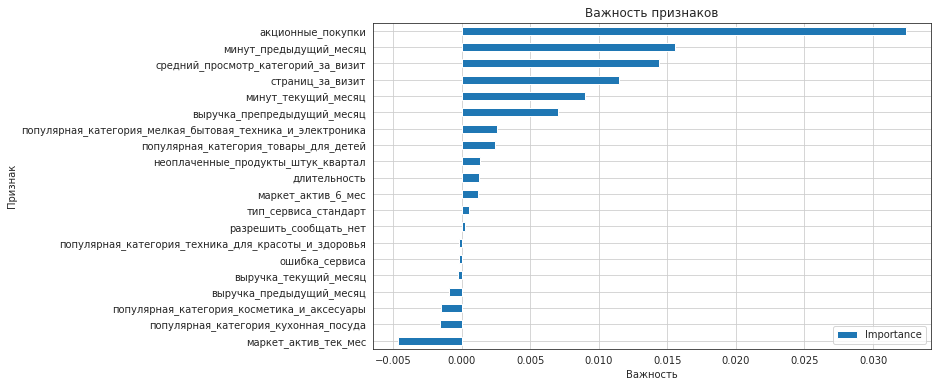

In [99]:
sns.set_style('white')
feature_importance = pd.DataFrame({'Feature': columns_name_list, 'Importance': permutation['importances_mean']})
feature_importance = feature_importance.sort_values('Importance', ascending=True)
feature_importance.plot(x='Feature', y='Importance', kind='barh', figsize=(10, 6), grid=True) 
plt.xlabel('Важность')
plt.ylabel('Признак')
plt.title('Важность признаков');

Из результатов графика можно сказать, что *наибольшее* влияние имеют признаки: `акционные_покупки`, `средний_просмотр_категорий_за_визит`, `минут_предыдущий_месяц`, `страниц_за_визит`, `минут_текущий_месяц`, `популярная_категория`; а *наименьшее* - `ошибка_сервиса`, `неоплаченные_продукты_штук_квартал`, `маркет_актив_тек_мес`.

### Сделаем выводы о значимости признаков

В результате оценки важности признаков были получены следующие результаты:
- наименее значимые признаки для модели были определены:
    - `ошибка_сервиса`
    - `маркет_актив_тек_мес`
    - `разрешить_сообщать`
- наиболее значимые признаки для модели были определены:
    - `акционные_покупки`
    - `страниц_за_визит`
    - `минут_предыдущий_месяц`
    - `средний_просмотр_категорий_за_визит`
    
Признак `страниц_за_визит` говорит о том, что чем больше страниц поупатель просматривает, тем вероятнее, что он останется на сайте в дальше и будет на него заходить снова. Признаки `минут_предыдущий_месяц` показывает, что чем больше времени покупатель на сайте, тем менее вероятнее, что он уйдет с сайта. Признак `средний_просмотр_категорий_за_визит` показывает, что, чем больше категорий покупатель просмотрел за визит на сайт, тем более вероятнее, что он продолжит им в дальнейшем пользоваться. Признак `ошибка_сервиса` и `разрешить_сообщать` меньше всего влияют на вероятность покупателя остаться на сайте.   

Исходя из этих наблюдений, для моделировании и принятии бизнес-решений можно порекомендовать:
- для покупателей, которые провели на сайте определенное количество *активных* минут, можно выдавать купон на покупку товара со скидкой (заранее об этом предупреждать клиентов не будем, чтобы они этим специально не пользовались)
- постараться увлечь покупателя товарами, чтобы он дальше пролистывал сайт и в итоге добавил или купил какой-нибудь товар; для этого, возможно, стоит сделать *необычный* интерфейс или добавить *странные интересные* всплывающие сообщения, которые не будут мешать обзору клиента в выборе товара 

**Промежуточный вывод:**

В результате анализа важности признаков были выполнены следующие шаги:
- оценили важность признаков для лучшей модели - `SVC` 
- построили и сравнили графики важности с помощью методов `SHAP` и `permutation_importance`
- сделали выводы о значимости признаков
- предложили рекомендации для моделировании и принятии бизнес-решений

## Сегментация покупателей

**Выполним сегментацию покупателей**

Используем результаты моделирования и данные о прибыльности покупателей.


Рассмотрим, какие признаки влияют на прибыль для компании. 

Объединим ранее созданный датафрейм `full_data` со всеми данными и датафрейм `money`:

In [100]:
search_df = full_data.merge(money, on='id', how='inner')

Для того чтобы определить взаимосвязь между признаками, воспользуемся `.phik_matrix()`, и посмотрим какие признаки влияют на `прибыль`:

interval columns not set, guessing: ['маркет_актив_6_мес', 'маркет_актив_тек_мес', 'акционные_покупки', 'средний_просмотр_категорий_за_визит', 'страниц_за_визит', 'выручка_препредыдущий_месяц', 'минут_предыдущий_месяц', 'минут_текущий_месяц', 'прибыль']


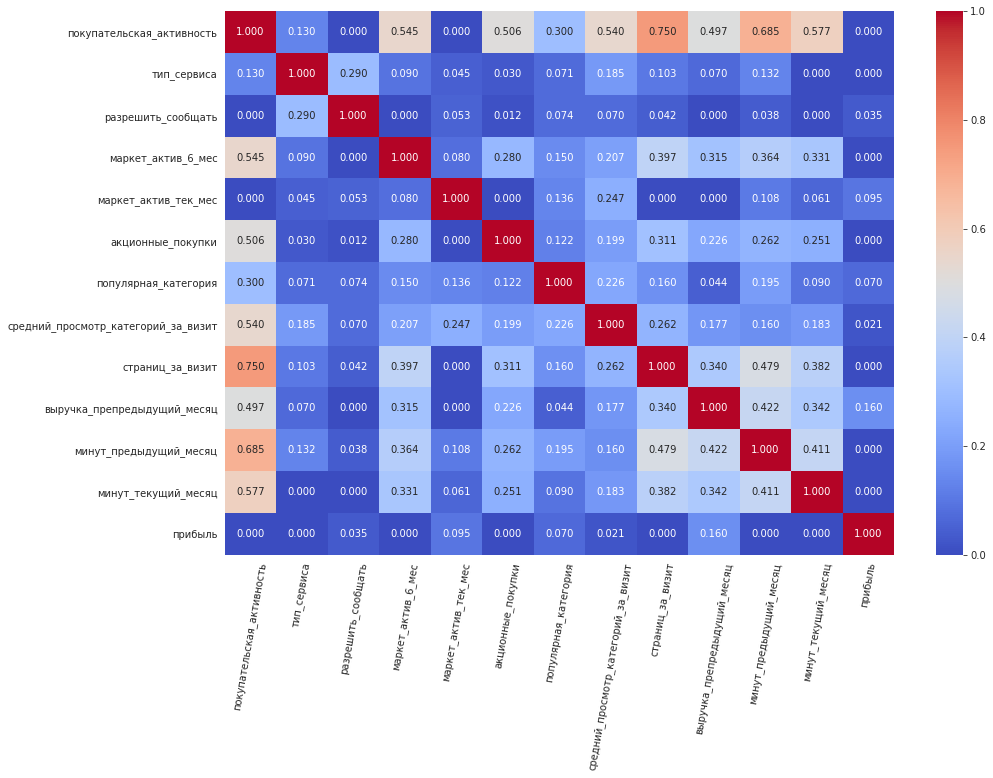

In [101]:
search_df
plt.figure(figsize=(15, 10))
sns.heatmap(search_df.drop(columns=['id', 'длительность', 'неоплаченные_продукты_штук_квартал', 'ошибка_сервиса', 'выручка_предыдущий_месяц', 
                                        'выручка_текущий_месяц']).phik_matrix(), annot=True, fmt='.3f', cmap='coolwarm')
plt.xticks(rotation=80)
plt.show()

Можно заметить, что признаки `минут_текущий_месяц`, `маркет_актив_тек_мес`, `выручка_препредыдущий_месяц` и `популярная_категория` влияют на признак `прибыль`.

Воспользуемся лучшей моделью.

In [102]:
# лучшая модель 
best_model_final = randomized_search.best_estimator_.named_steps['models']

Отмасштабированные и закодированные данные будем использовать из ранее созданных.

Снова обучим модель:

In [103]:
best_model_final.fit(X_train_preproc, y_train)

SVC(C=0.1, gamma=0.1, kernel='sigmoid', probability=True, random_state=42)

Спрогнозируем результат по покупательской активности: снизилась или осталась на прежнем уровне.

In [104]:
best_model_final.fit(X_train_preproc, y_train)
y_test_pred = best_model_final.predict(X_test_preproc)

In [105]:
# Получение вероятностей для тестовой выборки
y_test_proba = best_model_final.predict_proba(X_test_preproc)[:,1]
data = pd.DataFrame(zip(y_test, y_test_proba), columns = ['y_valid', 'y_proba'])

In [106]:
# зададим порог классификации такой, чтобы покупательская активность разделилась на части
threshold = 0.7

In [107]:
# Сделаем срез данных такой же длины, чтобы объединить с спрогнозированными данными и вероятностями
data_down = search_df.loc[:312].drop(columns=['покупательская_активность'])

Добавим в новый датафрейм данные тестовой выборки и полученные вероятности:

In [108]:
data_down['y_valid'] = data['y_valid']
data_down['y_proba'] = data['y_proba']

In [109]:
# Добавим новый столбец 'y_pred_0_7': вероятность будет проверяться на порог классификации 
# и делать предсказание с новым порогом классификации
data_down['y_pred_0_7'] = data['y_proba'].apply(lambda y: 1 if (y > threshold) else 0)

In [110]:
# Рассмотрим первые строки сформированного датафрейма
data_down.head()

,id,тип_сервиса,разрешить_сообщать,маркет_актив_6_мес,маркет_актив_тек_мес,длительность,акционные_покупки,популярная_категория,средний_просмотр_категорий_за_визит,неоплаченные_продукты_штук_квартал,...,страниц_за_визит,выручка_предыдущий_месяц,выручка_препредыдущий_месяц,выручка_текущий_месяц,минут_предыдущий_месяц,минут_текущий_месяц,прибыль,y_valid,y_proba,y_pred_0_7
0,215349,премиум,да,4.4,4,819,0.75,товары_для_детей,4,4,...,5,5216.0,4472.0,4971.6,12,10,4.16,0,0.005856,0
1,215350,стандарт,нет,4.9,3,539,0.14,домашний_текстиль,5,2,...,5,5457.5,4826.0,5058.4,8,13,3.13,1,0.999996,1
2,215351,стандарт,да,3.2,5,896,0.99,товары_для_детей,5,0,...,4,6158.0,4793.0,6610.4,11,13,4.87,0,0.101988,0
3,215352,стандарт,нет,5.1,3,1064,0.94,товары_для_детей,3,2,...,2,5807.5,4594.0,5872.5,8,11,4.21,1,0.877419,1
4,215353,стандарт,да,3.3,4,762,0.26,домашний_текстиль,4,1,...,4,4738.5,5124.0,5388.5,10,10,3.95,1,0.812229,1


Рассмотрим распределение вероятности того, что покупатель уйдет или останется относительно прибыли:

<Figure size 1080x864 with 0 Axes>

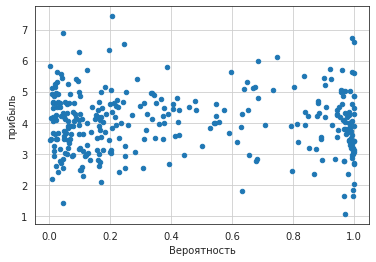

In [111]:
plt.figure(figsize=(15,12))
data_down.plot.scatter(x='y_proba', y='прибыль', grid = True)
plt.xlabel('Вероятность')
plt.ylabel('прибыль')
plt.show()

Из графика рассеяния можно сказать, что большая часть покупателей останется и не уйдет с сайта, то есть их покупательская активность останется на прежнем уровне.

Далее рассмотрим сегмент пользователей, чья покупательская активность **снизилась**, и проанализируем возможные причины к этому и предложим методы их возможного решения.

Визуализируем информацию из сформированного датафрейма учитывая, что данные в столбце `'y_pred_0_7'` равны `1`. Создадим функцию `graphics`, для визуализации гистограмм:

In [112]:
# функция визуализации графиков
# в функцию передаётся: датафрейм, датафрейм столбец датафрейма, название оси Х, название оси У
def graphics(dataframe, search_df, columns, measure_x, measure_y):
    plt.figure(figsize=(10, 8))
    # Вывод графиков гистограммы
    dataframe[columns].plot(kind='hist', bins=50, grid=True, color='blue')
    search_df[columns].plot(kind='hist', bins=50, color='red', alpha=0.5,  grid=True)
    plt.xlabel(measure_x)
    plt.ylabel(measure_y)

In [113]:
# необходимый для визуализации набор столбцов 
data_down_col = data_down.drop(columns=['id','маркет_актив_тек_мес', 'тип_сервиса', 'разрешить_сообщать', 'длительность',
                        'неоплаченные_продукты_штук_квартал', 'ошибка_сервиса', 'популярная_категория',
                        'y_valid','y_proba', 'y_pred_0_7']).columns

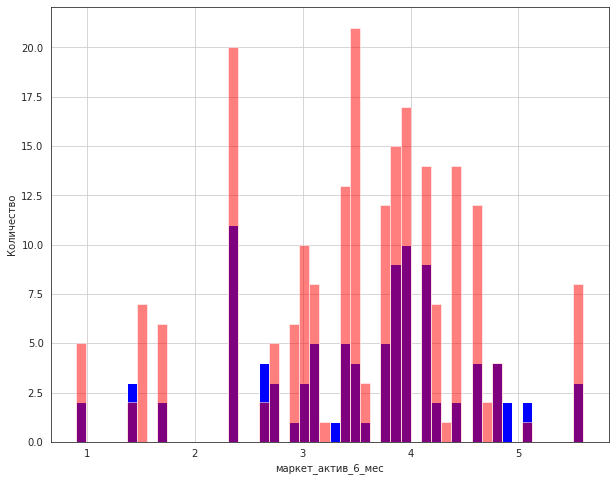

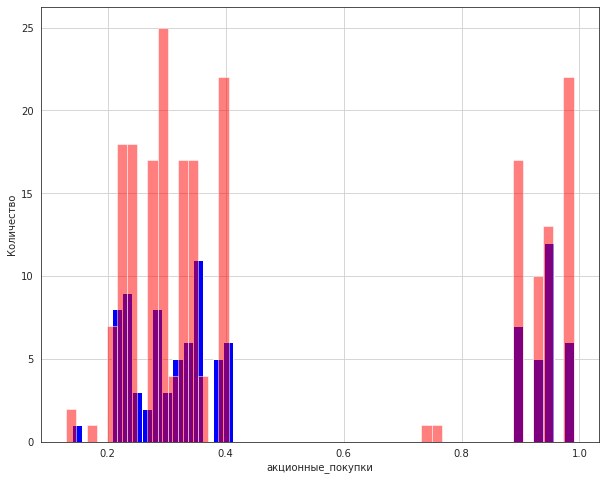

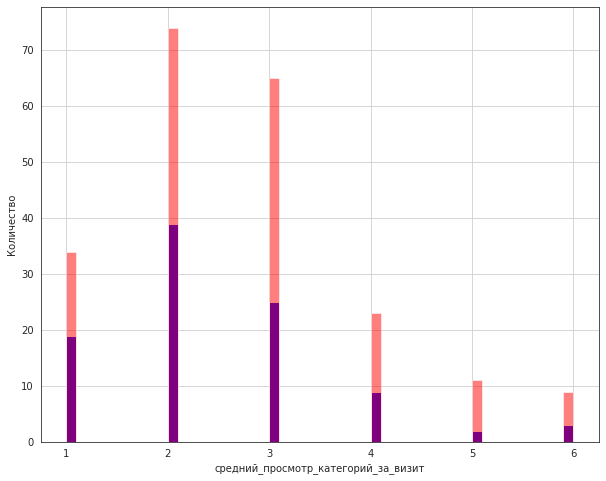

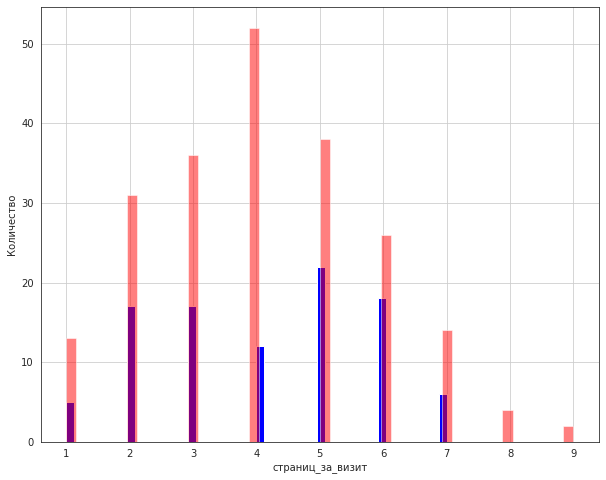

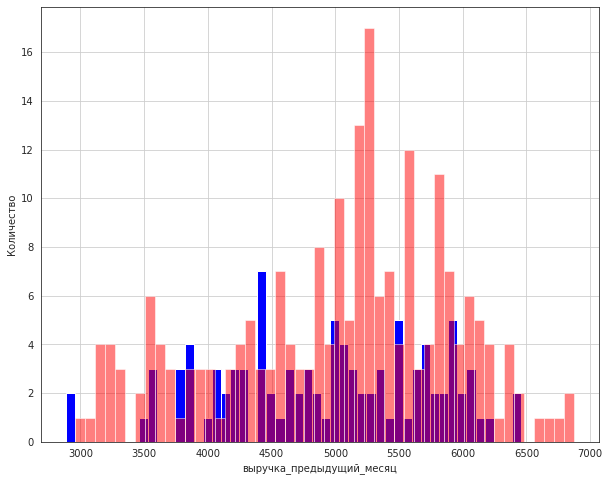

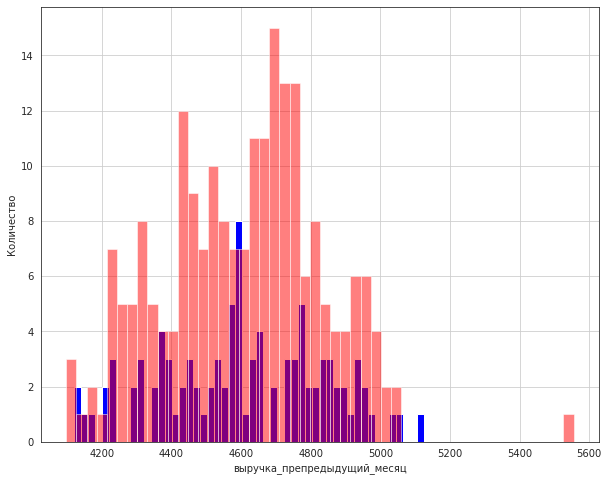

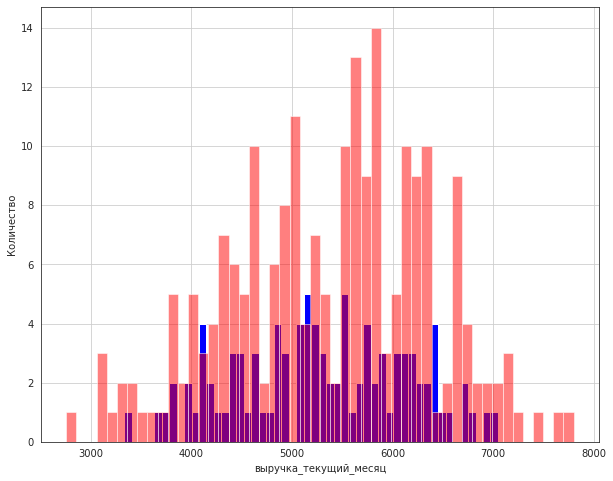

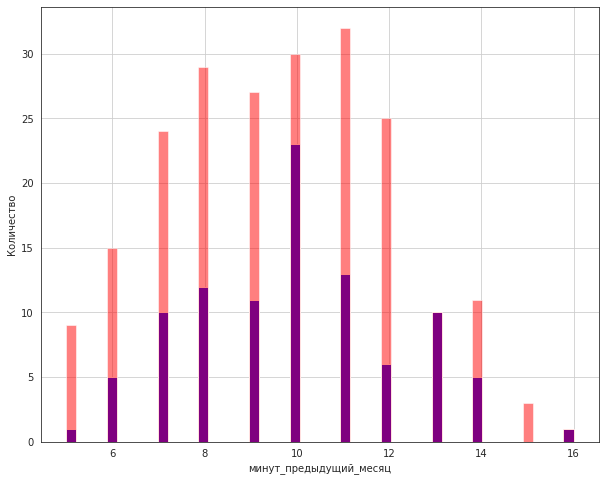

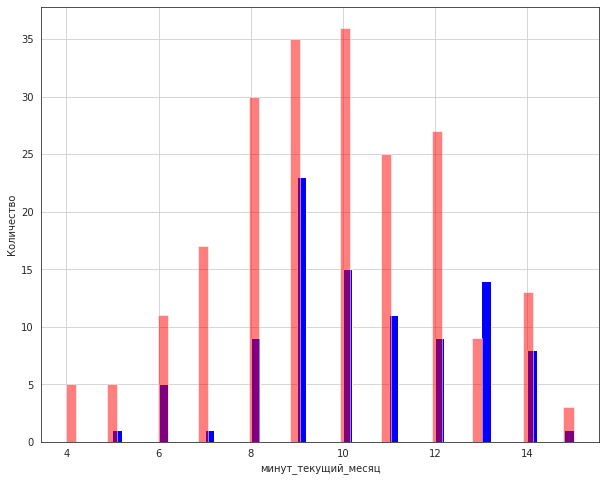

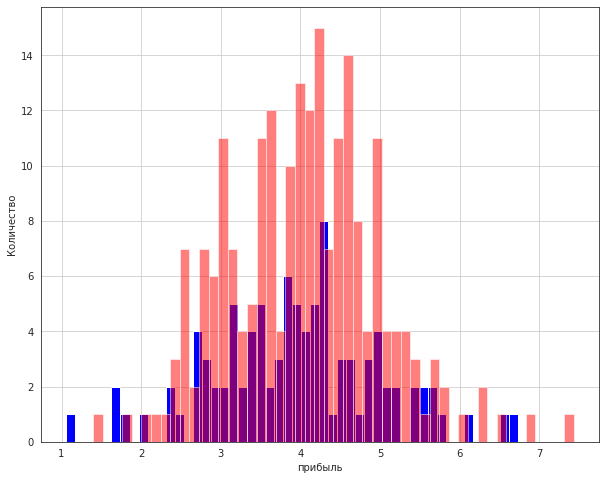

In [114]:
# построение гистограмм
for i in range(len(data_down_col)):
    graphics(data_down.query('y_pred_0_7 == 1'), data_down.query('y_pred_0_7 == 0'), data_down_col[i], data_down_col[i], 'Количество' )

Из результатов визуализации необходимых нам данных можно говорить следующее:
- график прибыли из-за покупателей, чья активность понизилась, имеет волнообразный вид
- после посещения 2-3 страниц за визит график активности резко падает вниз у пользователей со сниженной активностью, после снова возрастает 
- данный сегмент покупателей смотрит максимум 2 категории товаров
- на графике акционных долей виден резкий скачок после 0.8
- среднее количество страниц за визит у постоянных пользователей имеет возрастающе-убывающий вид графика, а у сниженных - больше похож на постоянный
- выручка за препредыдущий месяц во много раз превосходит выручку пользователей со сниженной активностью

Исходя из полученных данных можно предложить следующие возможные решения для увелечения покупательской активности:
- необходимо увеличить количество категорий или число товара в этих категориях, так как возможно, что покупатель просто напросто не находит нужный товар и уходит с сайта (и вероятнее всего на него больше не зайдёт, так как будет понимать, что там не нужных ему товаров) 
- не вводить слишком часто акции, так как это привлекает клиентов, которые покупают всё по низкой цене и мы получается продаем себе в убыток
- ввести индивидуальные купоны - данная вещь будет очень полезна, так как покупатели, которые часто пользуются сервисом смогут получать - своего рода - привелегии, и это удержит их в использовании нашего сервиса
- сделать удобный и необычный интерфейс сайта, чтобы клиенту было удобно искать нужный на сайте товар и просматривать страницы с ними, и одновременно интересно находиться на сайте

## Общий вывод


**Описание поставленной задачи:**
1. Необходимо промаркировать уровень финансовой активности постоянных покупателей. В компании принято выделять два уровня активности: «снизилась», если клиент стал покупать меньше товаров, и «прежний уровень».
2. Собрать данные по клиентам по группам
3. Нужно построить модель, которая предскажет вероятность снижения покупательской активности клиента в следующие три месяца.
4. При анализе включить дополнительные данные финансового департамента о прибыльности клиента: какой доход каждый покупатель приносил компании за последние три месяца.
5. Используя данные модели и данные о прибыльности клиентов, нужно выделить сегменты покупателей и разработать для них персонализированные предложения.

Все выше перечисленные шаги были выполнены и рекомендации по улучшению принятии бизнес-решений предложены.

**Описание исходных данных:**
1. Файл `market_file.csv`:
    - `id` — номер покупателя в корпоративной базе данных.
    - `Покупательская активность` — рассчитанный класс покупательской активности (целевой признак): «снизилась» или «прежний уровень».
    - `Тип сервиса` — уровень сервиса, например «премиум» и «стандарт».
    - Разрешить сообщать` — информация о том, можно ли присылать покупателю дополнительные предложения о товаре. Согласие на это даёт покупатель.
    - `Маркет_актив_6_мес` — среднемесячное значение маркетинговых коммуникаций компании, которое приходилось на покупателя за последние 6 месяцев. Это значение показывает, какое число рассылок, звонков, показов рекламы и прочего приходилось на клиента.
    - `Маркет_актив_тек_мес` — количество маркетинговых коммуникаций в текущем месяце.
    - `Длительность` — значение, которое показывает, сколько дней прошло с момента регистрации покупателя на сайте.
    - `Акционные_покупки` — среднемесячная доля покупок по акции от общего числа покупок за последние 6 месяцев.
    - `Популярная_категория` — самая популярная категория товаров у покупателя за последние 6 месяцев.
    - `Средний_просмотр_категорий_за_визит` — показывает, сколько в среднем категорий покупатель просмотрел за визит в течение последнего месяца.
    - `Неоплаченные_продукты_штук_квартал` — общее число неоплаченных товаров в корзине за последние 3 месяца.
    - `Ошибка_сервиса` — число сбоев, которые коснулись покупателя во время посещения сайта.
    - `Страниц_за_визит` — среднее количество страниц, которые просмотрел покупатель за один визит на сайт за последние 3 месяца.
    
    
2. Файл `market_money.csv`:
    - `id` — номер покупателя в корпоративной базе данных.
    - `Период` — название периода, во время которого зафиксирована выручка. Например, 'текущий_месяц' или 'предыдущий_месяц'.
    - `Выручка` — сумма выручки за период.
    
    
3. Файл `market_time.csv`:
    - `id` — номер покупателя в корпоративной базе данных.
    - `Период` — название периода, во время которого зафиксировано общее время.
    - `минут` — значение времени, проведённого на сайте, в минутах.
    
    
4. Файл `money.csv`:
    - `id` — номер покупателя в корпоративной базе данных.
    - `Прибыль` — значение прибыли.


В результате проведенного исследования было сделано и получено следующее:
- **Предобработка**:
    - изменили названия столбцов датафреймов - привели к "стандартизированному" виду (прописные буквы, "змеевидная запись")
    - обработали пропуски в столбцах датафреймов - выявили, что их нет
    - проверели и проанализировали данные на наличие дубликатов как явных, так и неявных
    - преобразовали неявные дубликаты там, где это было возможно
- **Исследовательский анализ**:
    - были рассмотрены количественные и категориальные переменные
    - были проанализированы выбросы во всех датафреймах
    - было проведено исследование на удаление или сохранение выбросов
    - рассмотрели процентное соотношение разных признаков по отношению ко всему количеству данных
- **Корреляционный анализ**:
    - построили тепловую карту матрицы корреляционных значений и проанализировали 
    - сделали выводы о взаимосвязи признаков
    - проанализировали графики и определили, что в данных нет мультиколлениарности, которая могла бы негативно повлиять на ход исследования

Для поиска *лучшей модели* был выбран класс `RandomizedSearchCV()`, в котором были обучены и проверены следующие модели: `KNeighborsClassifier()`, `DecisionTreeClassifier()`, `LogisticRegression()` и `SVC()`. Прежде чем начать обучение, были также созданы пайплайны для разных признаков, общий пайплайн для подготовки данных и итоговый пайплайн. В процессе посика лучшей модели также находились и возможные гиперпараметры, которые способствовали её улучшению. 


**Лучшей моделью** был признан метод опорных векторов `SVC()` со следующими гиперпараметрами: `C=0.1`, `gamma=0.1`, `kernel='sigmoid'`. 

Метрика *ROC-AUC* на тренировочной и тестовой выборках показала результаты *0.896694* и *0.914331* соответственно. Данные показатели являются очень хорошими.

**Анализ важности признаков и рекомендации по бизнес-решениям:**

Для удержания покупательской активности на сайте:
- для покупателей, которые провели на сайте определенное количество *активных* минут, можно выдавать купон на покупку товара со скидкой (заранее об этом предупреждать клиентов не будем, чтобы они этим специально не пользовались)
- постараться увлечь покупателя товарами, чтобы он дальше пролистывал сайт и в итоге добавил или купил какой-нибудь товар; для этого, возможно, стоит сделать *необычный* интерфейс или добавить *странные интересные* всплывающие сообщения, которые не будут мешать обзору клиента в выборе товара

Для изучения был выбран сегмент покупателей, с высокой вероятностью снижения покупательской активности и наиболее высокой прибыльностью.

Из проведенного анализа были выдвинуты следующие предложения:
- необходимо увеличить количество категорий или число товара в этих категориях, так как возможно, что покупатель просто напросто не находит нужный товар и уходит с сайта (и вероятнее всего на него больше не зайдёт, так как будет понимать, что там не нужных ему товаров) 
- не вводить слишком часто акции, так как это привлекает клиентов, которые покупают всё по низкой цене и мы получается продаем себе в убыток
- ввести индивидуальные купоны - данная вещь будет очень полезна, так как покупатели, которые часто пользуются сервисом смогут получать - своего рода - привелегии, и это удержит их в использовании нашего сервиса
- сделать удобный и необычный интерфейс сайта, чтобы клиенту было удобно искать нужный на сайте товар и просматривать страницы с ними, и одновременно интересно находиться на сайте